<a href="https://colab.research.google.com/github/sayyidul/mental_health_prediction/blob/main/3_Mental_Health_Experiment(Fix_Thesis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import io

In [ ]:
# 2. Load Dataset
# ==========================================================
# MENGHUBUNGKAN GOOGLE DRIVE DATASET
# ==========================================================
from google.colab import drive
import pandas as pd
import os

# Mount Google Drive
drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/03 Dataset/mental_health_selected5.csv'
df = pd.read_csv(data_path)

Mounted at /content/drive


In [ ]:
# 3. ENCODING (LABEL ENCODING)
# Mengubah kategori menjadi angka (0 dan 1)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])    # Female=0, Male=1 (biasanya urut abjad)
df['Academic'] = le.fit_transform(df['Academic']) # Grad=0, Under=1
df['Dep'] = le.fit_transform(df['Dep'])           # No=0, Yes=1
df['inter_dom'] = le.fit_transform(df['inter_dom']) # Dom=0, Inter=1
df['Religion'] = le.fit_transform(df['Religion']) # Do you consider yourself religious? No= 0 yes=1
df['Suicide'] = le.fit_transform(df['Suicide']) # Suicide=0, Not Suicide=1

# Menampilkan 5 baris pertama untuk pengecekan
print("Data setelah encoding:")
print(df.head())

Data setelah encoding:
   Gender  inter_dom  Academic   Age  Stay  Japanese  English  Religion  \
0       1          1         0  24.0   5.0       3.0      5.0         1   
1       1          1         0  28.0   1.0       4.0      4.0         0   
2       1          1         0  25.0   6.0       4.0      4.0         1   
3       0          1         0  29.0   1.0       2.0      3.0         0   
4       0          1         0  28.0   1.0       1.0      3.0         0   

   Suicide  ToSC  ...  Friends  Parents  Relative  Profess  Doctor  Reli  \
0        0  34.0  ...      5.0      6.0       3.0      2.0     4.0   1.0   
1        0  48.0  ...      7.0      7.0       4.0      4.0     4.0   1.0   
2        0  41.0  ...      3.0      3.0       1.0      1.0     1.0   1.0   
3        0  37.0  ...      5.0      5.0       5.0      5.0     2.0   2.0   
4        0  37.0  ...      5.0      5.0       2.0      5.0     5.0   5.0   

   Alone  Others  ToDep  Dep  
0    3.0     4.0    0.0    0  
1    1.

**Catatan Penting**: *Untuk Heatmap kita menggunakan ToDep drop Dep, sedangkan saat pemodelan klasifikasi kita menggunakan Dep drop ToDep*

In [ ]:
# 4. KORELASI YANG LEBIH BERSIH
# Kita buat salinan dataframe khusus untuk korelasi
df_corr = df.copy()

# Hapus kolom 'Dep' agar tidak 'membocorkan' hubungan yang sudah pasti dengan 'ToDep'
# Kita ingin melihat hubungan variabel LAIN terhadap ToDep
df_corr = df_corr.drop(columns=['Dep'])

# Hitung korelasi
correlation_matrix = df_corr.corr()

# Tampilkan korelasi terhadap ToDep
print("\nKorelasi Variabel terhadap Skor Depresi (ToDep):")
print(correlation_matrix['ToDep'].sort_values(ascending=False))


Korelasi Variabel terhadap Skor Depresi (ToDep):
ToDep        1.000000
Suicide      0.544551
Afear        0.348630
APD          0.340256
AMiscell     0.333342
Alone        0.309697
APH          0.309254
AGuilt       0.305948
ACS          0.274327
Others       0.241072
Academic     0.171033
AHome        0.168587
Profess      0.063483
Stay         0.051581
Japanese     0.036548
Doctor      -0.031114
English     -0.036452
Reli        -0.036490
inter_dom   -0.049659
Partner     -0.050096
Gender      -0.056841
Age         -0.115263
Friends     -0.115297
Religion    -0.127425
Relative    -0.146194
Parents     -0.170580
ToSC        -0.551795
Name: ToDep, dtype: float64


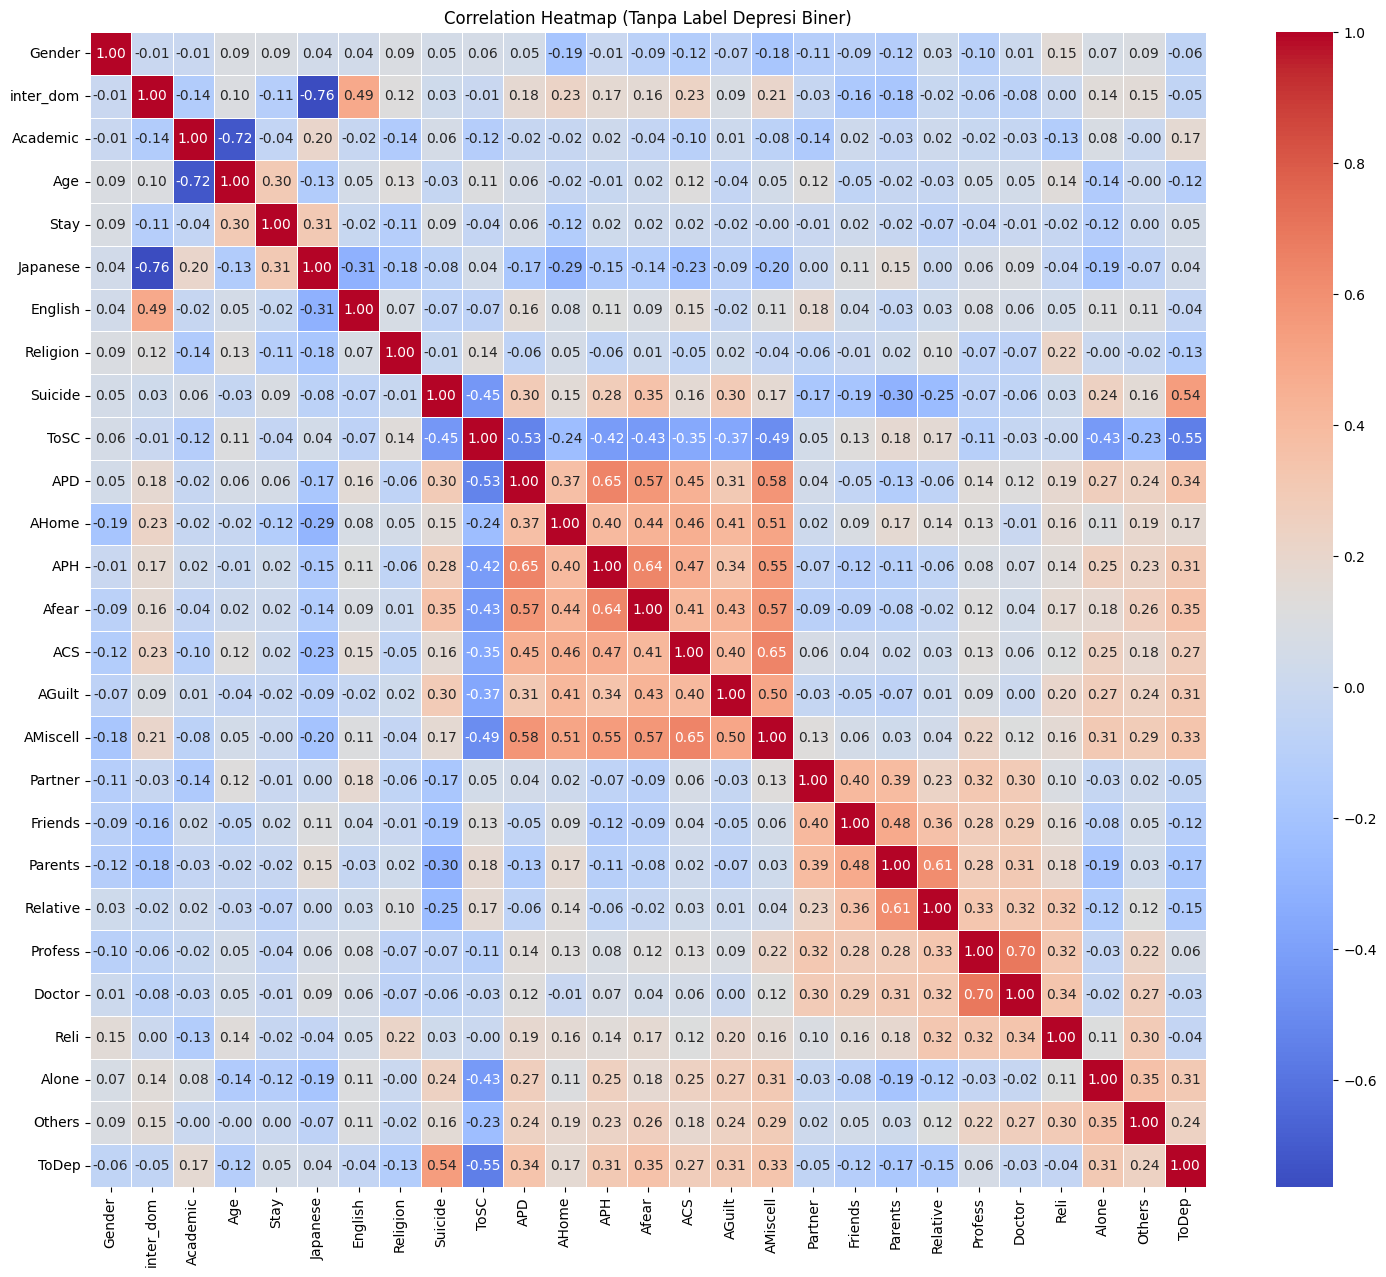

In [ ]:
# 5. VISUALISASI HEATMAP
plt.figure(figsize=(18, 15))
# Masking diagonal (opsional, agar tidak penuh angka 1.0 di tengah)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Tanpa Label Depresi Biner)')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Scikit-Learn & XGBoost
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Import Model-Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, StackingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [ ]:
# ==========================================
# 1. PERSIAPAN DATA
# ==========================================

# X = Fitur (Hapus Dep dan ToDep)
X = df.drop(columns=['Dep','ToDep'])
# y = Target
y = df['Dep']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# STANDARDISASI (SCALING) Z-Score Normalization (Standardisasi)
# Sangat penting untuk SVM dan Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tampilkan contoh data hasil proses
print("Contoh data siap training (5 baris pertama X_train_scaled):")
print(X_test_scaled[:5])

Contoh data siap training (5 baris pertama X_train_scaled):
[[ 1.36137186  0.55215763 -3.40414972  2.54096999 -0.85183606  0.73139424
   0.37123267 -0.77266741 -0.55935984  1.15347676 -1.22883696 -0.6516811
  -0.96782513 -1.06320199 -1.17846987 -0.93290236 -1.48774073  1.17912048
   1.49572714  1.2700126   0.49709062  0.66193965  0.84433997 -0.63701921
  -0.96814446 -0.73700107]
 [-0.73455316 -1.81107703  0.29375911 -0.66184951 -0.85183606  1.49864113
  -0.73215332 -0.77266741 -0.55935984  1.04785245 -1.22883696 -0.6516811
  -0.96782513 -0.73909198 -1.17846987 -0.93290236 -1.08507229  0.30600012
   1.49572714  1.2700126   1.58257421  2.34830972  2.63926136 -0.63701921
  -0.96814446 -0.73700107]
 [ 1.36137186  0.55215763  0.29375911 -0.66184951 -0.85183606 -0.03585266
   0.37123267 -0.77266741 -0.55935984  0.30848223 -0.24821132  0.34446001
   0.67780715  0.55734805 -0.0286558   0.08308291  0.6598243   0.30600012
  -0.07846437 -0.17564004 -0.58839298  2.34830972  0.84433997 -0.63701921


In [ ]:
print(X.head())

   Gender  inter_dom  Academic   Age  Stay  Japanese  English  Religion  \
0       1          1         0  24.0   5.0       3.0      5.0         1   
1       1          1         0  28.0   1.0       4.0      4.0         0   
2       1          1         0  25.0   6.0       4.0      4.0         1   
3       0          1         0  29.0   1.0       2.0      3.0         0   
4       0          1         0  28.0   1.0       1.0      3.0         0   

   Suicide  ToSC  ...  AMiscell  Partner  Friends  Parents  Relative  Profess  \
0        0  34.0  ...      27.0      5.0      5.0      6.0       3.0      2.0   
1        0  48.0  ...      10.0      7.0      7.0      7.0       4.0      4.0   
2        0  41.0  ...      14.0      3.0      3.0      3.0       1.0      1.0   
3        0  37.0  ...      21.0      5.0      5.0      5.0       5.0      5.0   
4        0  37.0  ...      31.0      5.0      5.0      5.0       2.0      5.0   

   Doctor  Reli  Alone  Others  
0     4.0   1.0    3.0     4.

In [ ]:
# ==========================================================
# MENAMPILKAN BOBOT (COEFFICIENT) & INTERCEPT LOGISTIC REGRESSION
# Dilatih pada SELURUH dataset (268 sampel) — sama seperti
# model yang digunakan pada aplikasi Streamlit
# ==========================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Scaling pada seluruh data (X = 268 sampel, 26 fitur)
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# Latih ulang Logistic Regression pada seluruh data
lr_final = LogisticRegression(max_iter=217, random_state=42)
lr_final.fit(X_scaled_full, y)

# Tampilkan intercept (b)
print(f"Intercept (b) = {lr_final.intercept_[0]:.6f}")

# Tampilkan bobot (w) per fitur dalam bentuk tabel
df_bobot = pd.DataFrame({
    "Fitur": X.columns,
    "Bobot (w)": lr_final.coef_[0]
})
print(df_bobot.to_string(index=False))

# (Opsional) Tampilkan mean & std dari scaler — untuk perhitungan manual z-score
df_scaler = pd.DataFrame({
    "Fitur": X.columns,
    "Mean (μ)": scaler_full.mean_,
    "Std (σ)": scaler_full.scale_
})
print(df_scaler.to_string(index=False))

Intercept (b) = -0.715319
    Fitur  Bobot (w)
   Gender  -0.075846
inter_dom   0.302907
 Academic   0.323367
      Age   0.233634
     Stay   0.132521
 Japanese   0.084401
  English  -0.130507
 Religion  -0.122167
  Suicide   0.528217
     ToSC  -0.697944
      APD  -0.150492
    AHome  -0.000126
      APH   0.117237
    Afear   0.050636
      ACS  -0.003180
   AGuilt  -0.284099
 AMiscell   0.231077
  Partner   0.292146
  Friends  -0.261895
  Parents   0.415804
 Relative  -0.281223
  Profess  -0.071285
   Doctor  -0.062279
     Reli   0.006872
    Alone   0.011432
   Others   0.245114
    Fitur  Mean (μ)  Std (σ)
   Gender  0.365672 0.481618
inter_dom  0.750000 0.433013
 Academic  0.921642 0.268734
      Age 20.873134 2.760115
     Stay  2.149254 1.324327
 Japanese  3.097015 1.303665
  English  3.649254 0.878919
 Religion  0.339552 0.473557
  Suicide  0.227612 0.419291
     ToSC 37.473881 9.216876
      APD 15.414179 6.162908
    AHome  9.608209 4.003665
      APH  9.138060 4.186818
 

# **ANALISIS KONVERGENSI**

Fold 1: Konvergen (datar) pada epoch 224
Fold 2: Konvergen (datar) pada epoch 257
Fold 3: Konvergen (datar) pada epoch 258
Fold 4: Konvergen (datar) pada epoch 345
Fold 5: Konvergen (datar) pada epoch 217
Fold 6: Konvergen (datar) pada epoch 280
Fold 7: Konvergen (datar) pada epoch 263
Fold 8: Konvergen (datar) pada epoch 267
Fold 9: Konvergen (datar) pada epoch 287
Fold 10: Konvergen (datar) pada epoch 283


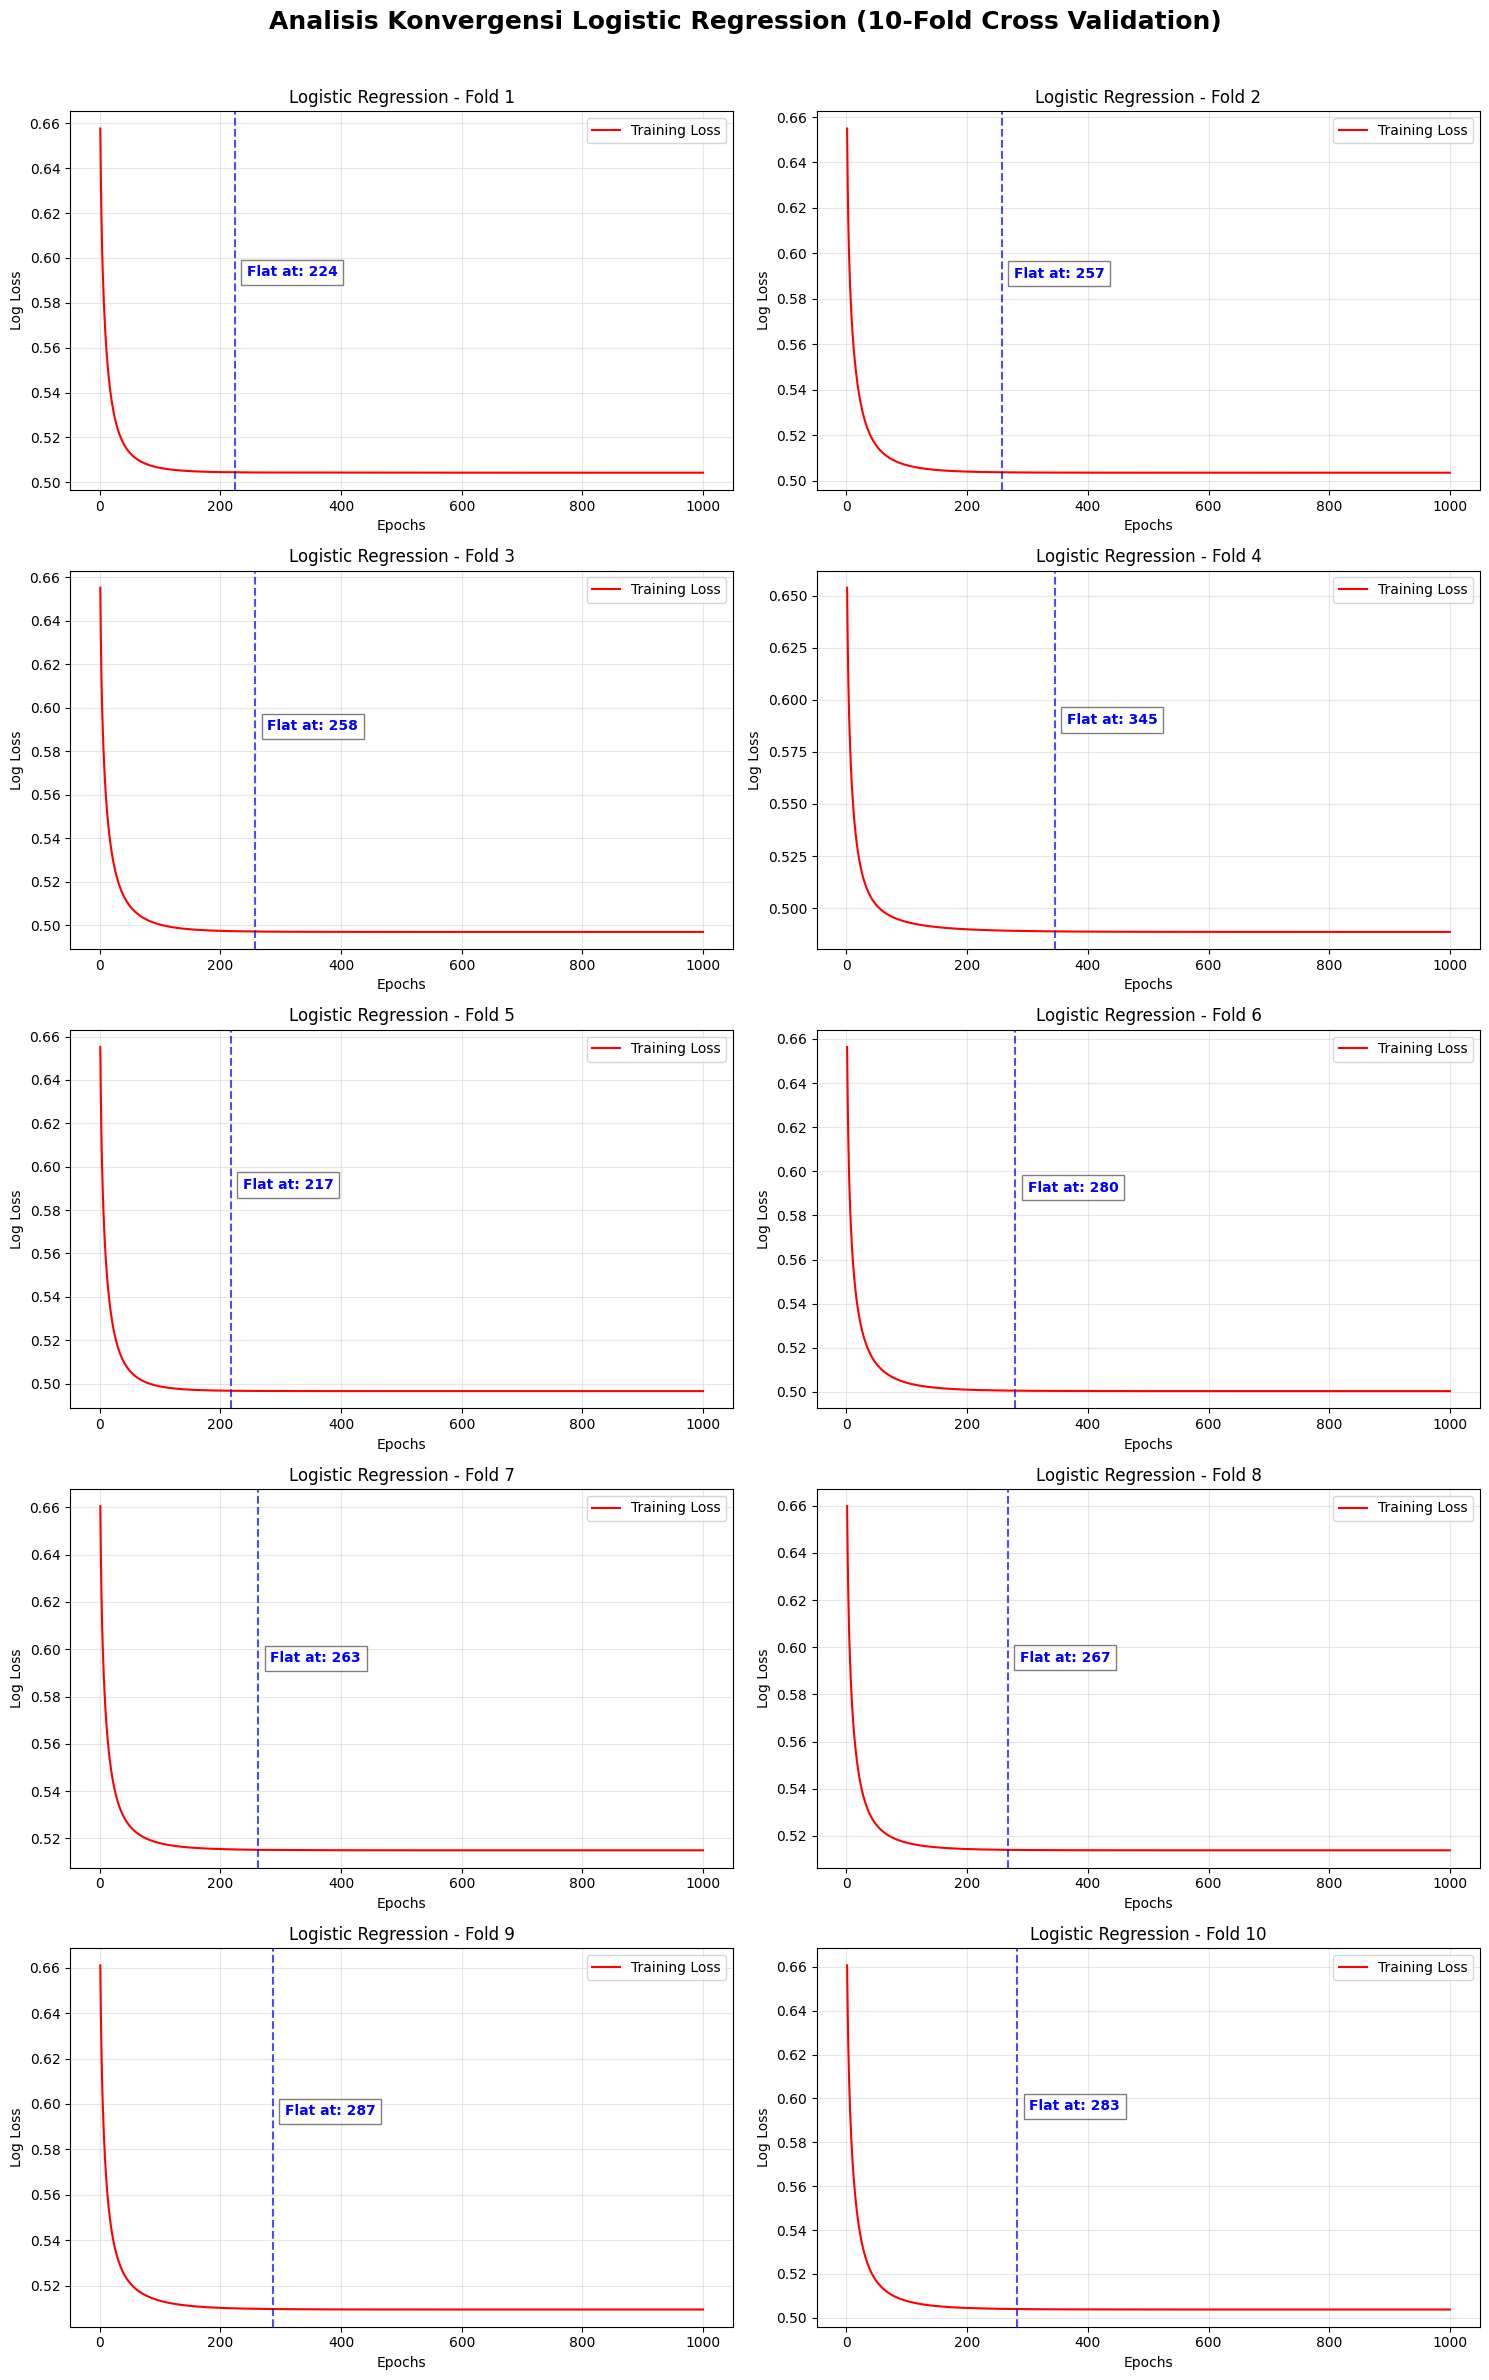

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# --- FUNGSI MENCARI ANGKA PASTI TITIK DATAR (PLATEAU) ---
def find_plateau_point(loss_values, threshold=1e-4, patience=50):
    for i in range(len(loss_values) - patience):
        window = loss_values[i : i + patience]
        diff = np.max(window) - np.min(window)
        if diff < threshold:
            return i + 1
    return len(loss_values)

# 1. Persiapan Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_array = y.values

# 2. GANTI KE 4 FOLD
n_folds = 10
epochs = 1000
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# 3. PERBESAR UKURAN FIGURE (Tinggi ditambah agar 10 grafik muat)
plt.figure(figsize=(15, 25))
fold_num = 1

for train_idx, val_idx in skf.split(X_scaled, y_array):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y_array[train_idx], y_array[val_idx]

    model = SGDClassifier(loss='log_loss', learning_rate='adaptive', eta0=0.001, warm_start=True)
    train_losses = []

    for e in range(epochs):
        model.partial_fit(X_train, y_train, classes=np.unique(y_array))
        train_losses.append(log_loss(y_train, model.predict_proba(X_train)))

    # HITUNG TITIK DATAR
    plateau_at = find_plateau_point(train_losses)

    # 4. SET SUBPLOT 5 baris x 2 kolom
    plt.subplot(5, 2, fold_num)

    # Plot hanya Garis Merah (Sesuai arahan dosen)
    plt.plot(range(1, epochs + 1), train_losses, 'r-', label='Training Loss')

    # Tambahkan Garis Vertikal Penanda Plateau
    plt.axvline(x=plateau_at, color='blue', linestyle='--', alpha=0.7)

    # Tambahkan Teks Angka
    plt.text(plateau_at + 20, np.max(train_losses)*0.9, f'Flat at: {plateau_at}',
             color='blue', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

    plt.title(f"Logistic Regression - Fold {fold_num}", fontsize=12)
    plt.xlabel("Epochs")
    plt.ylabel("Log Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    print(f"Fold {fold_num}: Konvergen (datar) pada epoch {plateau_at}")
    fold_num += 1

plt.suptitle("Analisis Konvergensi Logistic Regression (10-Fold Cross Validation)", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Memulai Training SVM 10-Fold... Mohon tunggu sebentar.
Fold 1: SVM konvergen pada epoch 10000
Fold 2: SVM konvergen pada epoch 10000
Fold 3: SVM konvergen pada epoch 10000
Fold 4: SVM konvergen pada epoch 10000
Fold 5: SVM konvergen pada epoch 10000
Fold 6: SVM konvergen pada epoch 934
Fold 7: SVM konvergen pada epoch 479
Fold 8: SVM konvergen pada epoch 10000
Fold 9: SVM konvergen pada epoch 10000
Fold 10: SVM konvergen pada epoch 10000


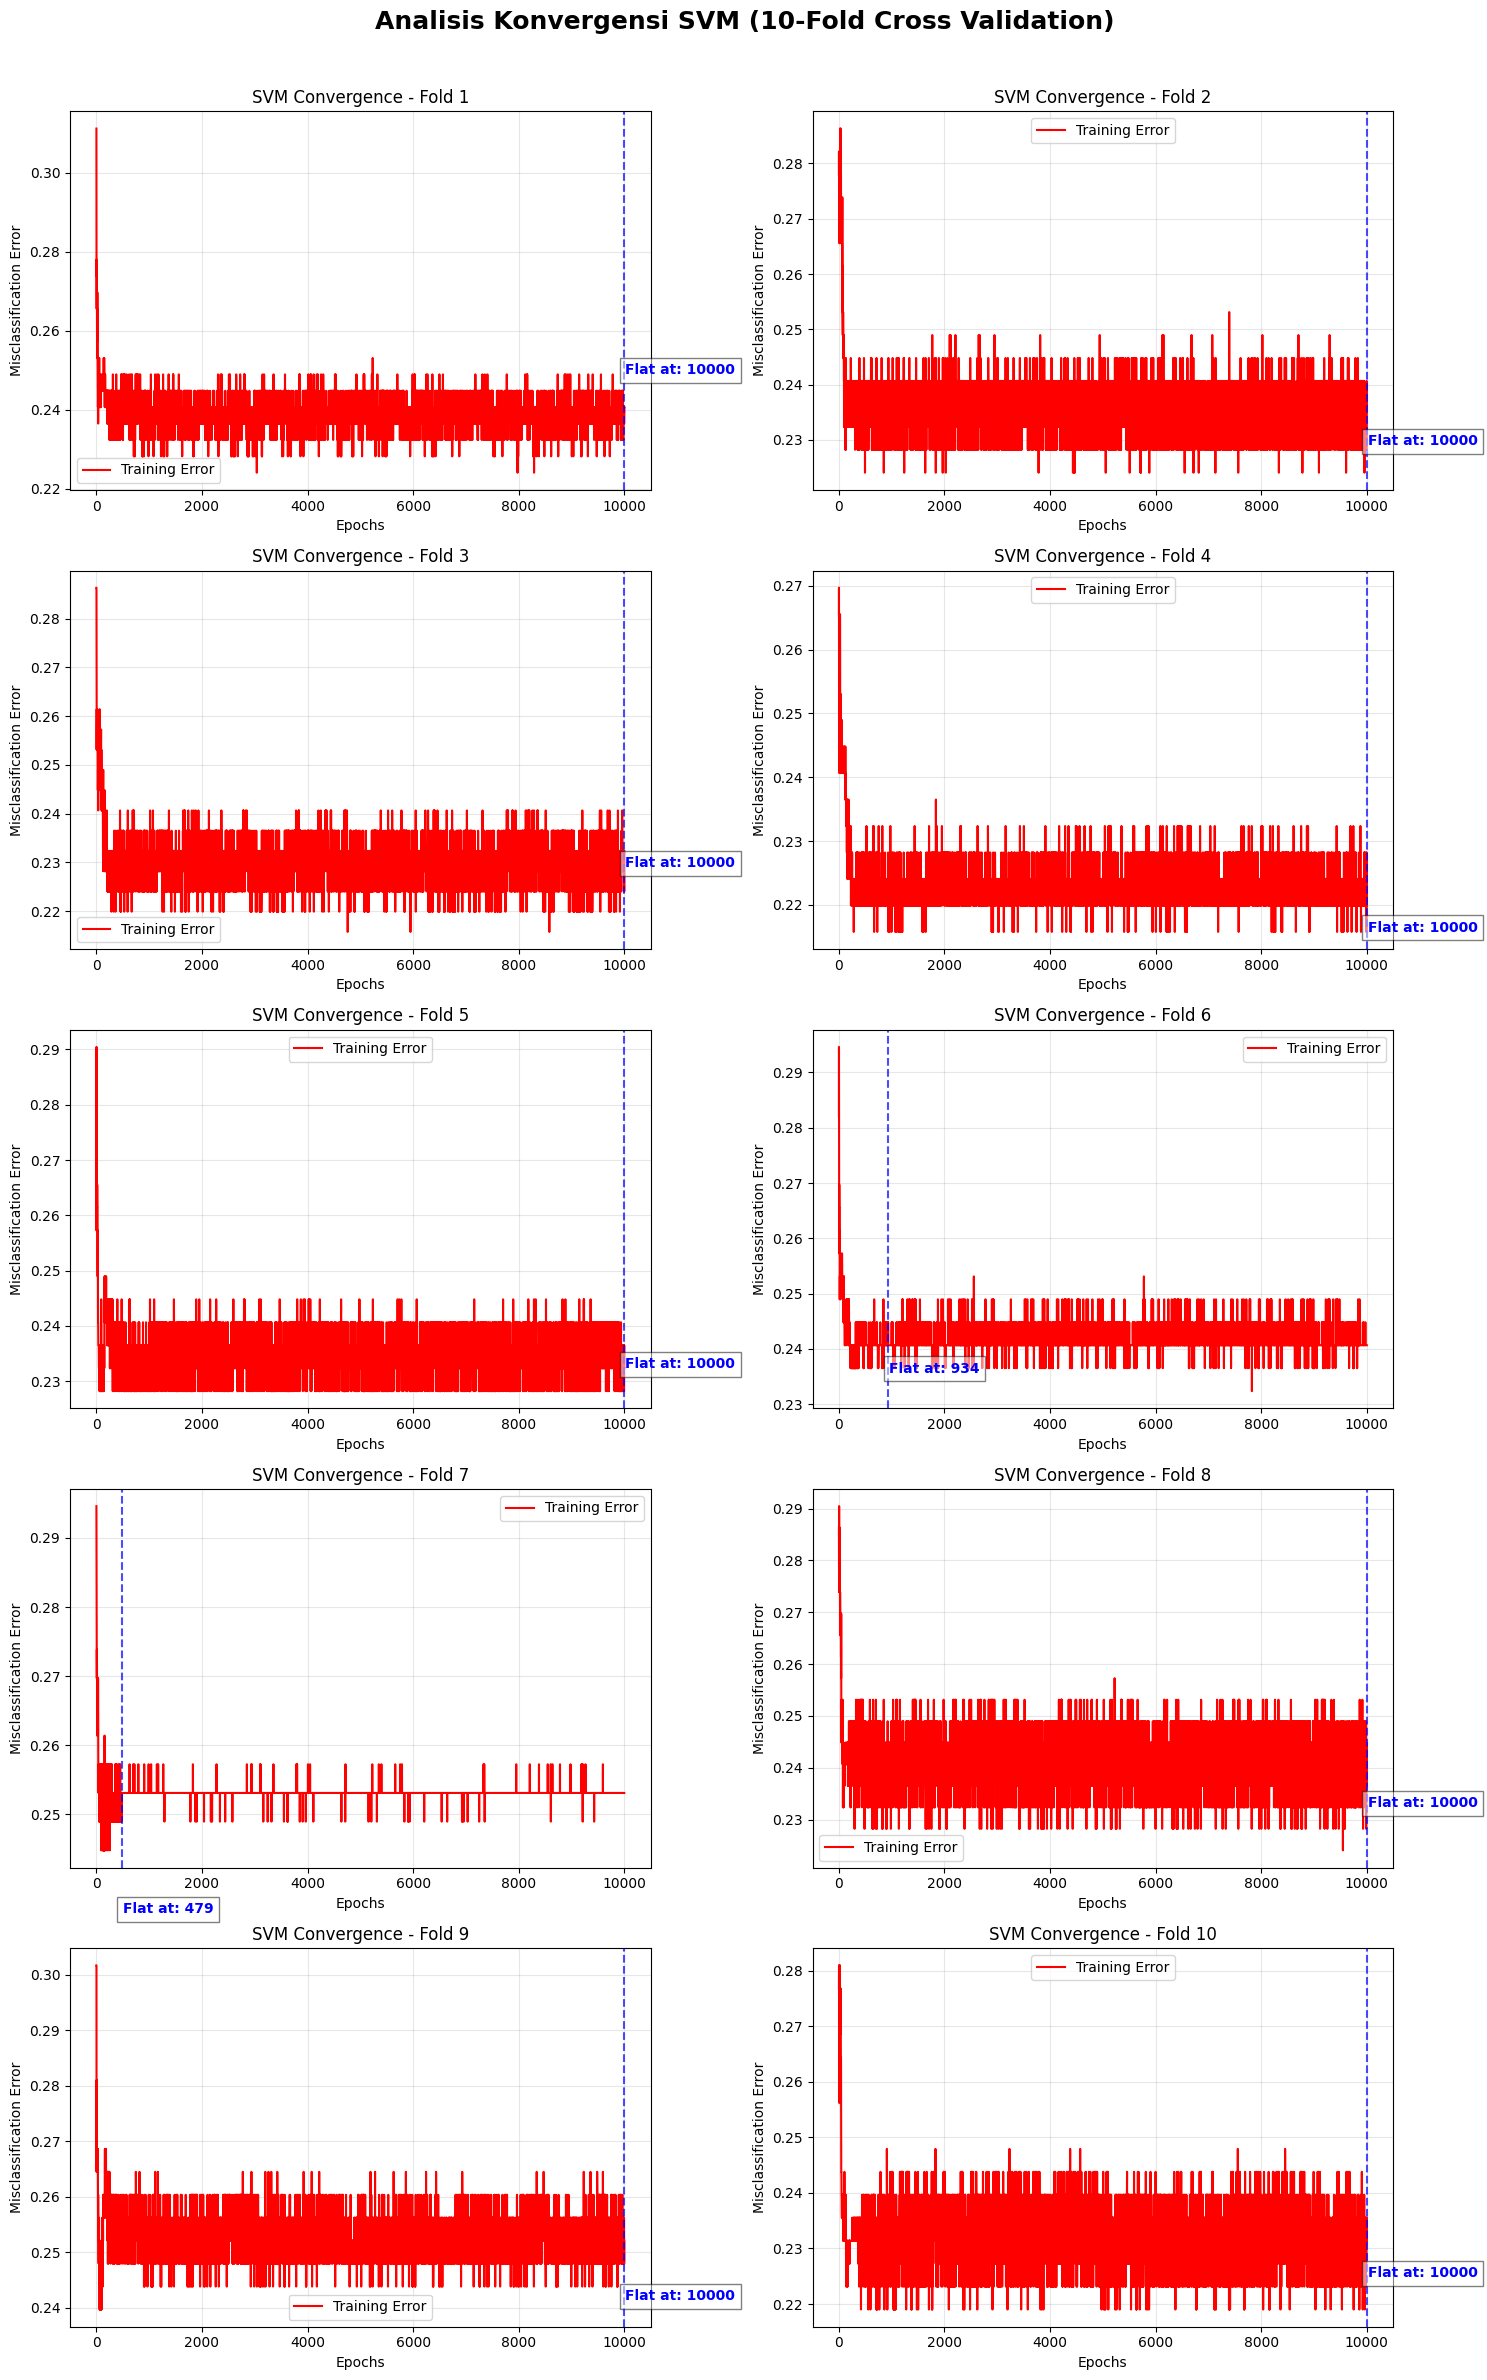

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# --- FUNGSI MENCARI ANGKA PASTI TITIK DATAR (PLATEAU) ---
def find_plateau_point(loss_values, threshold=1e-4, patience=50):
    """
    Mencari epoch di mana perubahan error sudah sangat kecil secara konsisten.
    """
    for i in range(len(loss_values) - patience):
        window = loss_values[i : i + patience]
        diff = np.max(window) - np.min(window)
        if diff < threshold:
            return i + 1
    return len(loss_values)

# 1. Persiapan Data (Wajib Scaling untuk SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_array = y.values

# 2. Konfigurasi 10-Fold & 1000 Epoch
n_folds = 10
epochs = 10000
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# 3. Setting Kanvas (Tinggi agar 10 grafik terlihat jelas)
plt.figure(figsize=(15, 25))
fold_num = 1

print("Memulai Training SVM 10-Fold... Mohon tunggu sebentar.")

for train_idx, val_idx in skf.split(X_scaled, y_array):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y_array[train_idx], y_array[val_idx]

    # Menggunakan Hinge Loss untuk SVM
    # Learning rate dibuat adaptive agar konvergensi halus (tidak bergejolak parah)
    model = SGDClassifier(loss='hinge', learning_rate='adaptive', eta0=0.001, alpha=0.01, warm_start=True)

    train_errors = []

    for e in range(epochs):
        # Training satu epoch
        model.partial_fit(X_train, y_train, classes=np.unique(y_array))
        # Hitung Misclassification Error (1 - Accuracy)
        train_errors.append(1 - model.score(X_train, y_train))

    # --- HITUNG TITIK DATAR (PLATEAU) ---
    plateau_at = find_plateau_point(train_errors)

    # 4. Plotting (5 baris x 2 kolom)
    plt.subplot(5, 2, fold_num)

    # Plot hanya Garis Merah (Sesuai arahan dosen)
    plt.plot(range(1, epochs + 1), train_errors, 'r-', label='Training Error')

    # Tambahkan Garis Vertikal Penanda Plateau
    plt.axvline(x=plateau_at, color='blue', linestyle='--', alpha=0.7)

    # Tambahkan Teks Angka Plateau
    plt.text(plateau_at + 20, np.max(train_errors)*0.8, f'Flat at: {plateau_at}',
             color='blue', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

    plt.title(f"SVM Convergence - Fold {fold_num}", fontsize=12)
    plt.xlabel("Epochs")
    plt.ylabel("Misclassification Error")
    plt.legend()
    plt.grid(True, alpha=0.3)

    print(f"Fold {fold_num}: SVM konvergen pada epoch {plateau_at}")
    fold_num += 1

plt.suptitle("Analisis Konvergensi SVM (10-Fold Cross Validation)", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Memulai Training Random Forest 10-Fold (5000 Trees)...
Proses ini mungkin memakan waktu beberapa menit. Mohon tunggu.
Fold 1: Random Forest konvergen pada 1576 pohon.
Fold 2: Random Forest konvergen pada 298 pohon.
Fold 3: Random Forest konvergen pada 208 pohon.
Fold 4: Random Forest konvergen pada 841 pohon.
Fold 5: Random Forest konvergen pada 254 pohon.
Fold 6: Random Forest konvergen pada 539 pohon.
Fold 7: Random Forest konvergen pada 313 pohon.
Fold 8: Random Forest konvergen pada 520 pohon.
Fold 9: Random Forest konvergen pada 197 pohon.
Fold 10: Random Forest konvergen pada 230 pohon.


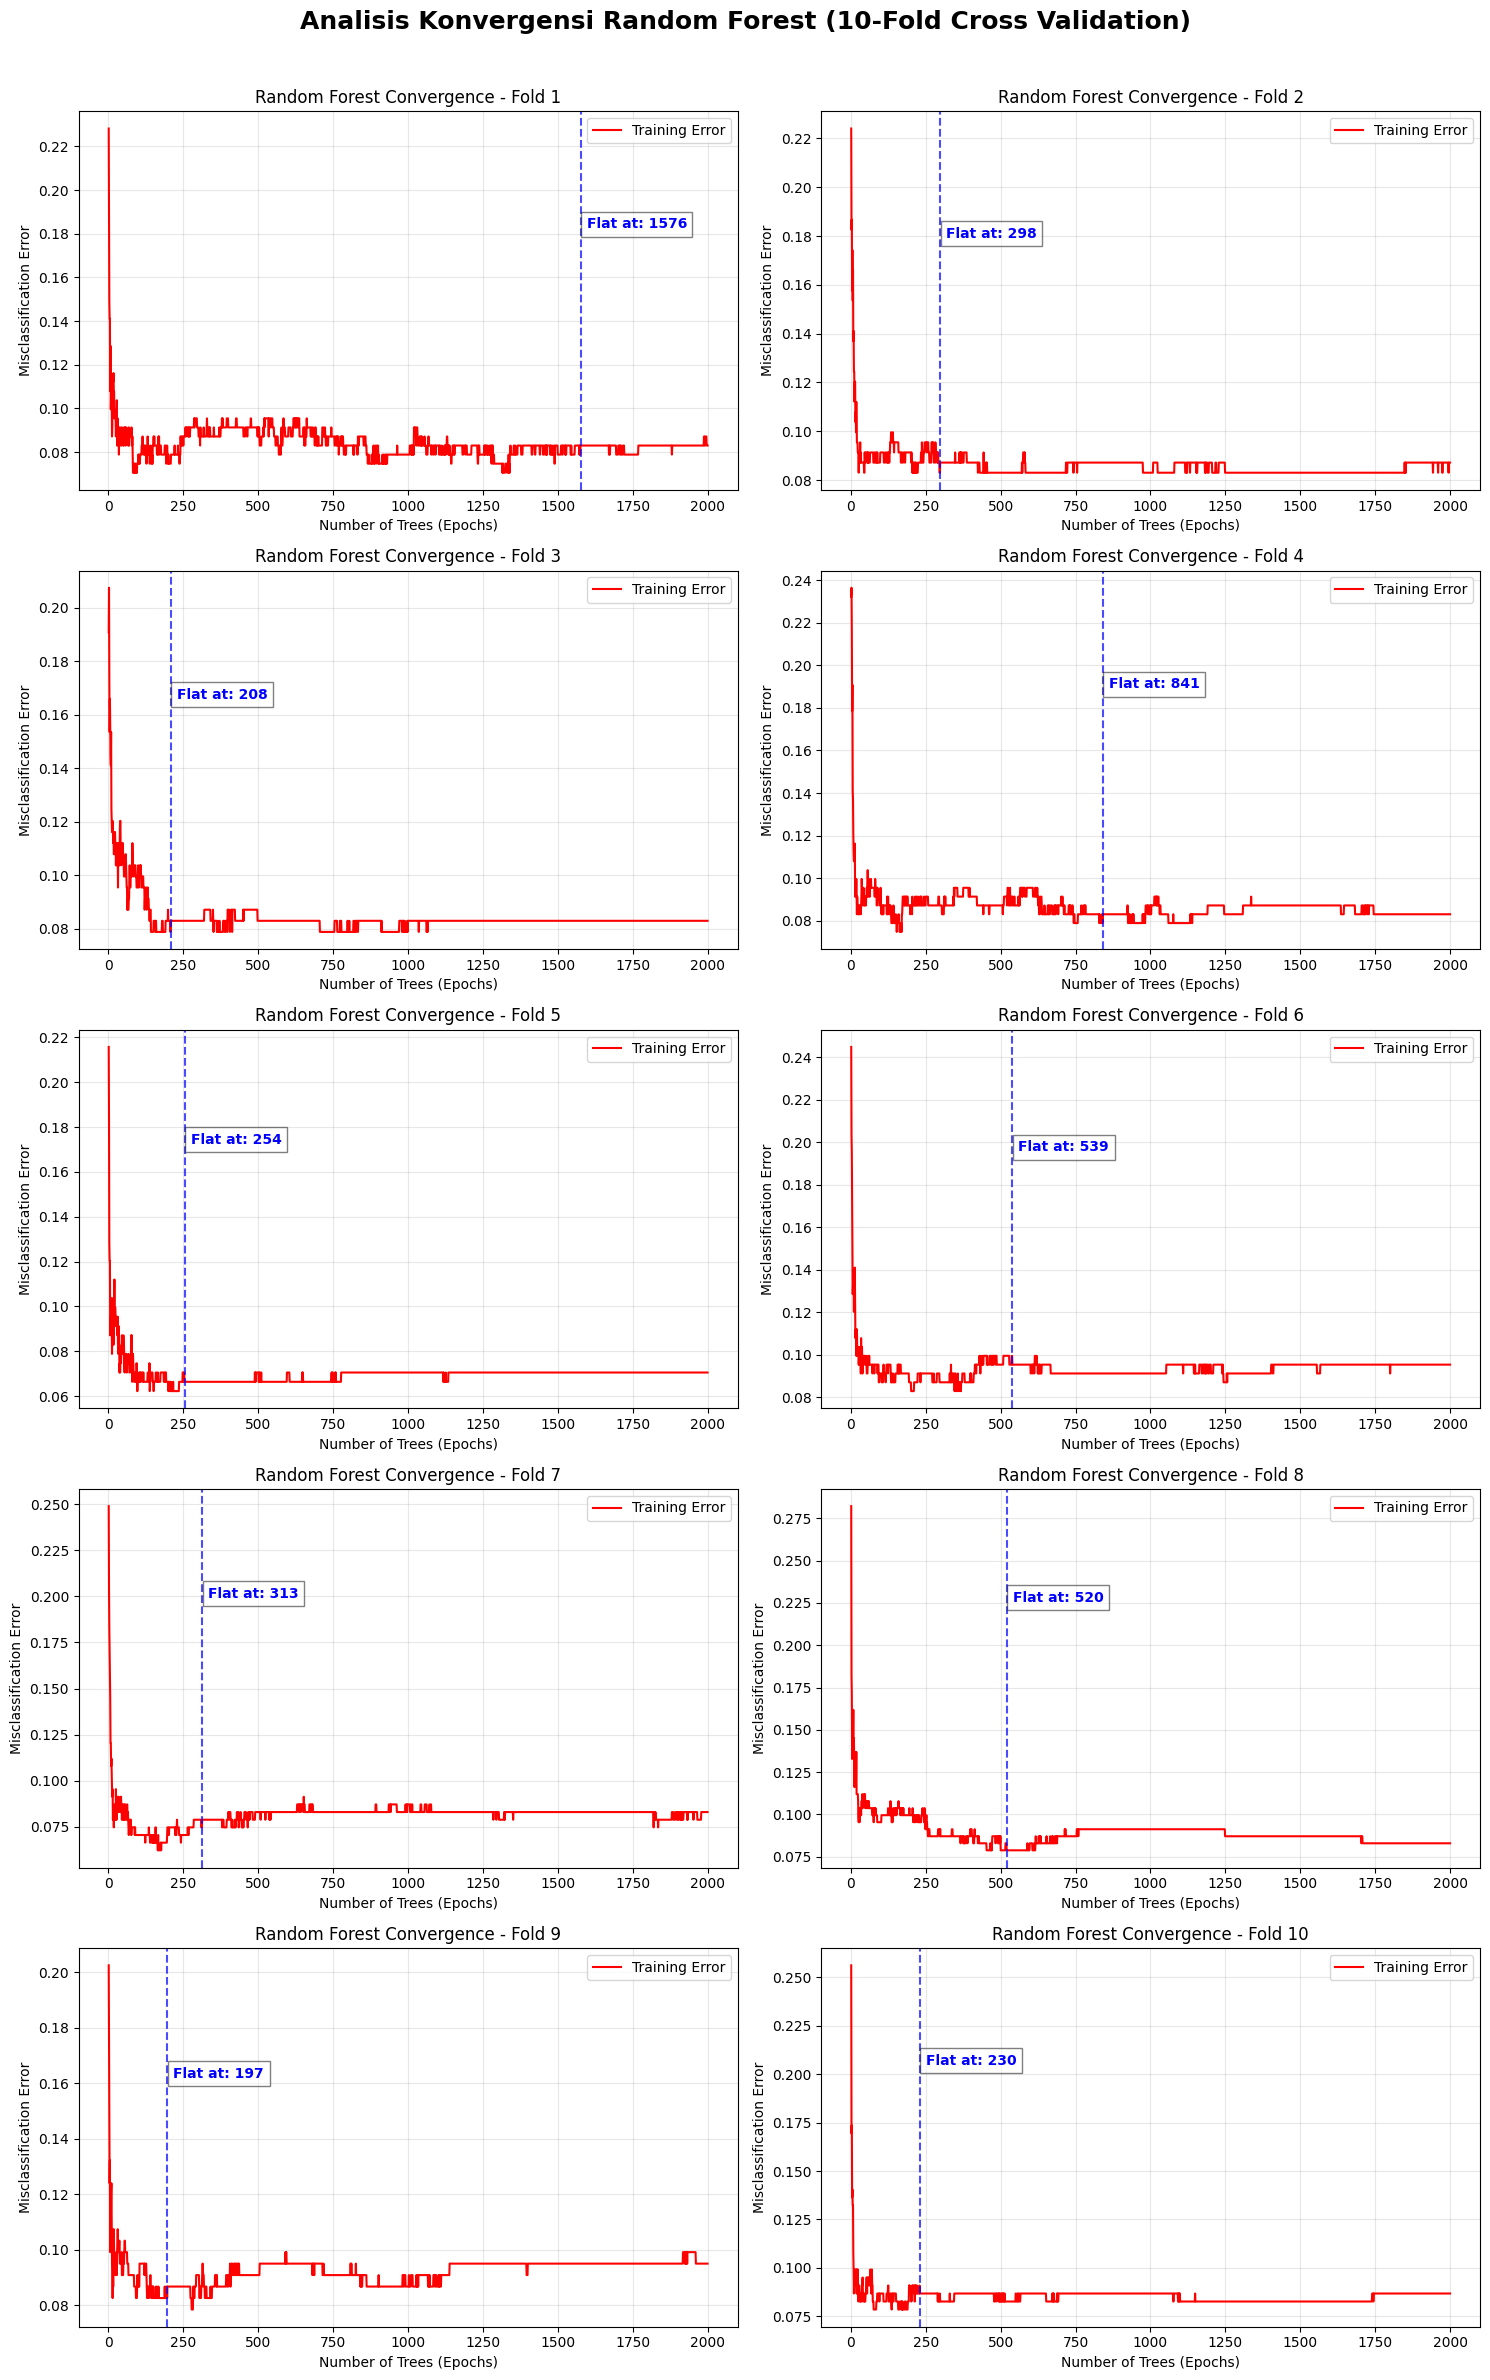

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# --- FUNGSI MENCARI ANGKA PASTI TITIK DATAR (PLATEAU) ---
def find_plateau_point(loss_values, threshold=1e-4, patience=50):
    """
    Mencari jumlah pohon (epoch) di mana error sudah sangat stabil.
    """
    for i in range(len(loss_values) - patience):
        window = loss_values[i : i + patience]
        diff = np.max(window) - np.min(window)
        if diff < threshold:
            return i + 1
    return len(loss_values)

# 1. Persiapan Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_array = y.values

# 2. Konfigurasi 10-Fold & 1000 Trees (Epochs)
n_folds = 10
epochs = 2000
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# 3. Setting Kanvas (Tinggi agar 10 grafik terlihat jelas)
plt.figure(figsize=(15, 25))
fold_num = 1

print("Memulai Training Random Forest 10-Fold (5000 Trees)...")
print("Proses ini mungkin memakan waktu beberapa menit. Mohon tunggu.")

for train_idx, val_idx in skf.split(X_scaled, y_array):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y_array[train_idx], y_array[val_idx]

    # Menggunakan warm_start agar efisien dalam menambah jumlah pohon satu per satu
    model = RandomForestClassifier(n_estimators=1, warm_start=True, max_depth=5, random_state=42, n_jobs=-1)

    train_errors = []

    for e in range(1, epochs + 1):
        model.n_estimators = e
        model.fit(X_train, y_train)
        # Hitung Misclassification Error (1 - Accuracy)
        train_errors.append(1 - model.score(X_train, y_train))

    # --- HITUNG TITIK DATAR (PLATEAU) ---
    plateau_at = find_plateau_point(train_errors)

    # 4. Plotting (5 baris x 2 kolom)
    plt.subplot(5, 2, fold_num)

    # Plot hanya Garis Merah (Sesuai arahan dosen)
    plt.plot(range(1, epochs + 1), train_errors, 'r-', label='Training Error')

    # Tambahkan Garis Vertikal Penanda Plateau
    plt.axvline(x=plateau_at, color='blue', linestyle='--', alpha=0.7)

    # Tambahkan Teks Angka Plateau
    plt.text(plateau_at + 20, np.max(train_errors)*0.8, f'Flat at: {plateau_at}',
             color='blue', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

    plt.title(f"Random Forest Convergence - Fold {fold_num}", fontsize=12)
    plt.xlabel("Number of Trees (Epochs)")
    plt.ylabel("Misclassification Error")
    plt.legend()
    plt.grid(True, alpha=0.3)

    print(f"Fold {fold_num}: Random Forest konvergen pada {plateau_at} pohon.")
    fold_num += 1

plt.suptitle("Analisis Konvergensi Random Forest (10-Fold Cross Validation)", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Memulai Training XGBoost 10-Fold (2000 Rounds)...
Fold 1: XGBoost konvergen (flat) pada round 2003
Fold 2: XGBoost konvergen (flat) pada round 2275
Fold 3: XGBoost konvergen (flat) pada round 2156
Fold 4: XGBoost konvergen (flat) pada round 2187
Fold 5: XGBoost konvergen (flat) pada round 2504
Fold 6: XGBoost konvergen (flat) pada round 2208
Fold 7: XGBoost konvergen (flat) pada round 2051
Fold 8: XGBoost konvergen (flat) pada round 2286
Fold 9: XGBoost konvergen (flat) pada round 2190
Fold 10: XGBoost konvergen (flat) pada round 2383


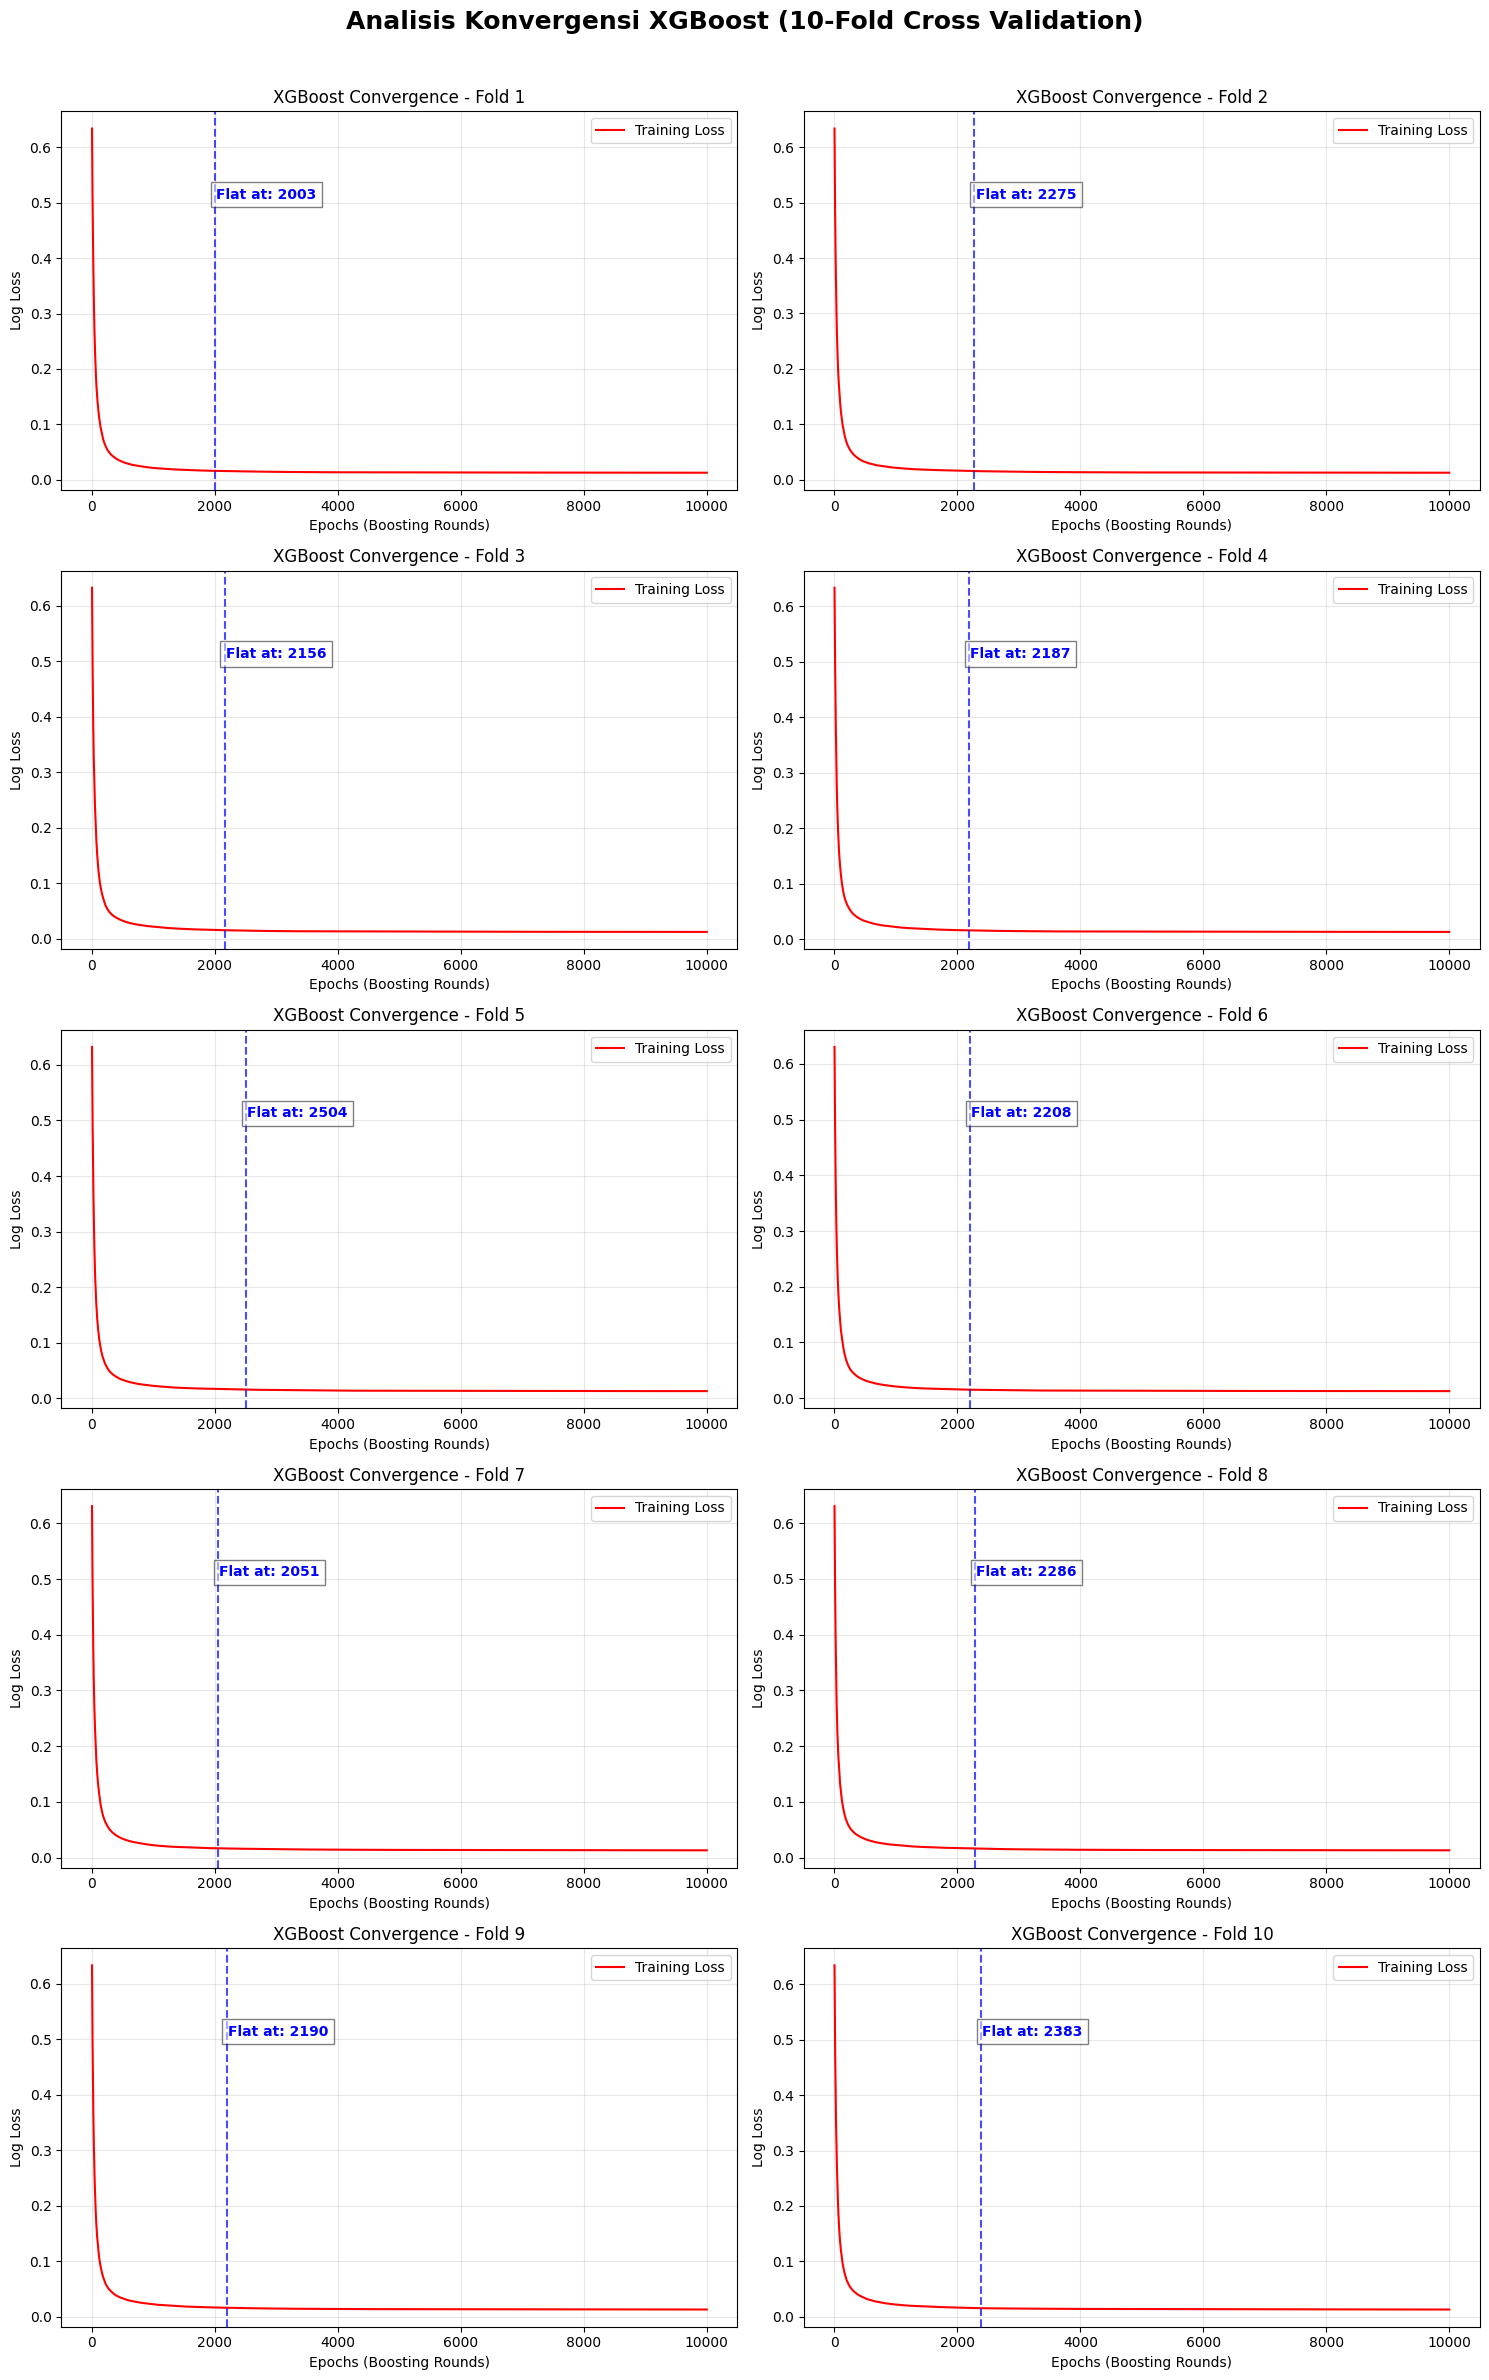

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# --- FUNGSI MENCARI ANGKA PASTI TITIK DATAR (PLATEAU) ---
def find_plateau_point(loss_values, threshold=1e-4, patience=50):
    """
    Mencari boosting round (epoch) di mana loss sudah sangat stabil.
    """
    for i in range(len(loss_values) - patience):
        window = loss_values[i : i + patience]
        diff = np.max(window) - np.min(window)
        if diff < threshold:
            return i + 1
    return len(loss_values)

# 1. Persiapan Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_array = y.values

# 2. Konfigurasi 10-Fold & 1000 Rounds (Epochs)
n_folds = 10
epochs = 10000
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# 3. Setting Kanvas (Layout 5x2 untuk 10 grafik)
plt.figure(figsize=(15, 25))
fold_num = 1

print("Memulai Training XGBoost 10-Fold (2000 Rounds)...")

for train_idx, val_idx in skf.split(X_scaled, y_array):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y_array[train_idx], y_array[val_idx]

    # Inisialisasi XGBoost
    # Learning rate (eta) disetel kecil agar penurunan loss terlihat halus dan presisi
    model = XGBClassifier(
        n_estimators=epochs,
        learning_rate=0.05,
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42
    )

    # Training dengan memantau hasil pada data training itu sendiri
    model.fit(X_train, y_train, eval_set=[(X_train, y_train)], verbose=False)

    # Ambil riwayat Log-Loss
    results = model.evals_result()
    train_losses = results['validation_0']['logloss']

    # --- HITUNG TITIK DATAR (PLATEAU) ---
    plateau_at = find_plateau_point(train_losses)

    # 4. Plotting (5 baris x 2 kolom)
    plt.subplot(5, 2, fold_num)

    # Plot hanya Garis Merah (Training Loss)
    plt.plot(range(1, epochs + 1), train_losses, 'r-', label='Training Loss')

    # Tambahkan Garis Vertikal Penanda Plateau (Warna Biru)
    plt.axvline(x=plateau_at, color='blue', linestyle='--', alpha=0.7)

    # Tambahkan Teks Label Angka Plateau
    plt.text(plateau_at + 20, np.max(train_losses)*0.8, f'Flat at: {plateau_at}',
             color='blue', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

    plt.title(f"XGBoost Convergence - Fold {fold_num}", fontsize=12)
    plt.xlabel("Epochs (Boosting Rounds)")
    plt.ylabel("Log Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    print(f"Fold {fold_num}: XGBoost konvergen (flat) pada round {plateau_at}")
    fold_num += 1

plt.suptitle("Analisis Konvergensi XGBoost (10-Fold Cross Validation)", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.linear_model import SGDClassifier
# from sklearn.metrics import log_loss
# from xgboost import XGBClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import StratifiedKFold

# # 1. Penyiapan Data & Scaler
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
# y_array = y.values

# # 2. KONFIGURASI REVISI (Epoch diperbanyak jadi 250)
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# epochs = 1000  # Dosen minta diperpanjang

# model_histories = {
#     "SVM (Hinge Loss)": {"train": np.zeros(epochs), "val": np.zeros(epochs)},
#     "Logistic Regression": {"train": np.zeros(epochs), "val": np.zeros(epochs)},
#     "Random Forest": {"train": np.zeros(epochs), "val": np.zeros(epochs)},
#     "XGBoost": {"train": np.zeros(epochs), "val": np.zeros(epochs)}
# }

# # 3. Proses Training Iteratif
# for train_idx, val_idx in skf.split(X_scaled, y_array):
#     X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
#     y_train, y_val = y_array[train_idx], y_array[val_idx]

#     # SVM & LR diperhalus learning rate-nya agar tidak terlalu zig-zag (divergen)
#     svm_iter = SGDClassifier(loss='hinge', learning_rate='adaptive', eta0=0.001, alpha=0.01, warm_start=True)
#     lr_iter = SGDClassifier(loss='log_loss', learning_rate='adaptive', eta0=0.001, warm_start=True)

#     for e in range(epochs):
#         svm_iter.partial_fit(X_train, y_train, classes=np.unique(y_array))
#         lr_iter.partial_fit(X_train, y_train, classes=np.unique(y_array))

#         # Simpan Error
#         model_histories["SVM (Hinge Loss)"]["train"][e] += (1 - svm_iter.score(X_train, y_train)) / 5
#         model_histories["SVM (Hinge Loss)"]["val"][e] += (1 - svm_iter.score(X_val, y_val)) / 5

#         model_histories["Logistic Regression"]["train"][e] += log_loss(y_train, lr_iter.predict_proba(X_train), labels=[0,1]) / 5
#         model_histories["Logistic Regression"]["val"][e] += log_loss(y_val, lr_iter.predict_proba(X_val), labels=[0,1]) / 5

#     # Random Forest (Menambah pohon satu per satu)
#     for e in range(1, epochs + 1):
#         rf = RandomForestClassifier(n_estimators=e, max_depth=5, random_state=42, n_jobs=-1)
#         rf.fit(X_train, y_train)
#         model_histories["Random Forest"]["train"][e-1] += (1 - rf.score(X_train, y_train)) / 5
#         model_histories["Random Forest"]["val"][e-1] += (1 - rf.score(X_val, y_val)) / 5

#     # XGBoost (Ditambah rounds-nya)
#     xgb = XGBClassifier(n_estimators=epochs, learning_rate=0.05) # LR diperkecil agar konvergen halus
#     xgb.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
#     results = xgb.evals_result()
#     model_histories["XGBoost"]["train"] += np.array(results['validation_0']['logloss']) / 5
#     model_histories["XGBoost"]["val"] += np.array(results['validation_1']['logloss']) / 5

# # 4. Visualisasi
# plt.figure(figsize=(15, 10))
# for i, (name, history) in enumerate(model_histories.items()):
#     plt.subplot(2, 2, i+1)
#     plt.plot(range(1, epochs + 1), history["train"], 'r-', label='Train Loss/Error')
#     plt.plot(range(1, epochs + 1), history["val"], 'g-', label='Val Loss/Error')
#     plt.title(f"Revisi: Loss/Error vs Epochs ({name})", fontweight='bold')
#     plt.xlabel("Epochs")
#     plt.ylabel("Loss / Error Rate")
#     plt.legend()
#     plt.grid(True, which='both', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()

# **1. ACCURACY**

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.ensemble import VotingClassifier, StackingClassifier # Tambah Stacking
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression # Untuk Meta-Learner di Stacking
import numpy as np

# Import Algoritma
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ==========================================================
# 1. Inisialisasi model dengan "Bobot" Titik Plateau
# ==========================================================

lr_model = LogisticRegression(max_iter=217, random_state=42)
svm_model = SVC(probability=True, max_iter=-1, random_state=42)
rf_model = RandomForestClassifier(n_estimators=197, random_state=42)
xgb_model = XGBClassifier(n_estimators=2003, learning_rate=0.05, eval_metric='logloss', random_state=42)

# Daftar estimator dasar untuk Ensemble
base_estimators = [
    ('lr', lr_model),
    ('svm', svm_model),
    ('rf', rf_model),
    ('xgb', xgb_model)
]

# 2. Definisikan daftar model dalam dictionary (DITAMBAH STACKING)
models = {
    "SVM": svm_model,
    "Random Forest": rf_model,
    "Logistic Regression": lr_model,
    "XGBoost": xgb_model,
    "Ensemble_Majority_Voting": VotingClassifier(
        estimators=base_estimators,
        voting='hard'
    ),
    "Ensemble_Stacking": StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(), # Meta-Learner untuk menggabungkan hasil
        cv=5
    )
}

# 3. Siapkan StratifiedKFold (Anda bisa ganti n_splits=10 jika ingin lebih akurat)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

all_model_scores = {}

# 4. Loop untuk setiap model
for model_name, model in models.items():
    print(f"--- Menjalankan Testing K-Fold: {model_name} ---")

    fold_num = 1
    scores = []

    for train_index, test_index in skf.split(X, y):
        # Membagi data
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Wajib Scaling agar konsisten
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Melatih model
        model.fit(X_train_scaled, y_train)

        # Prediksi dan
        predictions = model.predict(X_test_scaled)

        # menampilkan metrik
        cm = confusion_matrix(y_test, predictions)
        tn, fp, fn, tp = cm.ravel()
        print(f"  Fold {fold_num} → TP={tp}, TN={tn}, FP={fp}, FN={fn}")

        # evaluasi
        accuracy = accuracy_score(y_test, predictions)

        print(f"Fold {fold_num} Accuracy: {accuracy:.4f}")
        scores.append(accuracy)
        fold_num += 1

    all_model_scores[model_name] = scores
    print(f"Rata-rata Akurasi Akhir {model_name}: {np.mean(scores):.4f}")
    print("-" * 40 + "\n")

--- Menjalankan Testing K-Fold: SVM ---
  Fold 1 → TP=4, TN=29, FP=6, FN=15
Fold 1 Accuracy: 0.6111
  Fold 2 → TP=7, TN=30, FP=5, FN=12
Fold 2 Accuracy: 0.6852
  Fold 3 → TP=10, TN=29, FP=5, FN=10
Fold 3 Accuracy: 0.7222
  Fold 4 → TP=10, TN=31, FP=3, FN=9
Fold 4 Accuracy: 0.7736
  Fold 5 → TP=9, TN=31, FP=3, FN=10
Fold 5 Accuracy: 0.7547
Rata-rata Akurasi Akhir SVM: 0.7094
----------------------------------------

--- Menjalankan Testing K-Fold: Random Forest ---
  Fold 1 → TP=5, TN=28, FP=7, FN=14
Fold 1 Accuracy: 0.6111
  Fold 2 → TP=8, TN=31, FP=4, FN=11
Fold 2 Accuracy: 0.7222
  Fold 3 → TP=10, TN=28, FP=6, FN=10
Fold 3 Accuracy: 0.7037
  Fold 4 → TP=10, TN=30, FP=4, FN=9
Fold 4 Accuracy: 0.7547
  Fold 5 → TP=8, TN=31, FP=3, FN=11
Fold 5 Accuracy: 0.7358
Rata-rata Akurasi Akhir Random Forest: 0.7055
----------------------------------------

--- Menjalankan Testing K-Fold: Logistic Regression ---
  Fold 1 → TP=8, TN=30, FP=5, FN=11
Fold 1 Accuracy: 0.7037
  Fold 2 → TP=7, TN=28, FP

--- Menjalankan Testing K-Fold: SVM ---
Fold 1 Accuracy: 0.6111
Fold 2 Accuracy: 0.6852
Fold 3 Accuracy: 0.7222
Fold 4 Accuracy: 0.7736
Fold 5 Accuracy: 0.7547
Rata-rata Akurasi Akhir SVM: 0.7094
----------------------------------------

--- Menjalankan Testing K-Fold: Random Forest ---
Fold 1 Accuracy: 0.6111
Fold 2 Accuracy: 0.7222
Fold 3 Accuracy: 0.7037
Fold 4 Accuracy: 0.7547
Fold 5 Accuracy: 0.7358
Rata-rata Akurasi Akhir Random Forest: 0.7055
----------------------------------------

--- Menjalankan Testing K-Fold: Logistic Regression ---
  [Koefisien Fold 1 berhasil disimpan]
Fold 1 Accuracy: 0.7037
  [Koefisien Fold 2 berhasil disimpan]
Fold 2 Accuracy: 0.6481
  [Koefisien Fold 3 berhasil disimpan]
Fold 3 Accuracy: 0.6296
  [Koefisien Fold 4 berhasil disimpan]
Fold 4 Accuracy: 0.7736
  [Koefisien Fold 5 berhasil disimpan]
Fold 5 Accuracy: 0.7358
Rata-rata Akurasi Akhir Logistic Regression: 0.6982
----------------------------------------

--- Menjalankan Testing K-Fold: XGBoost

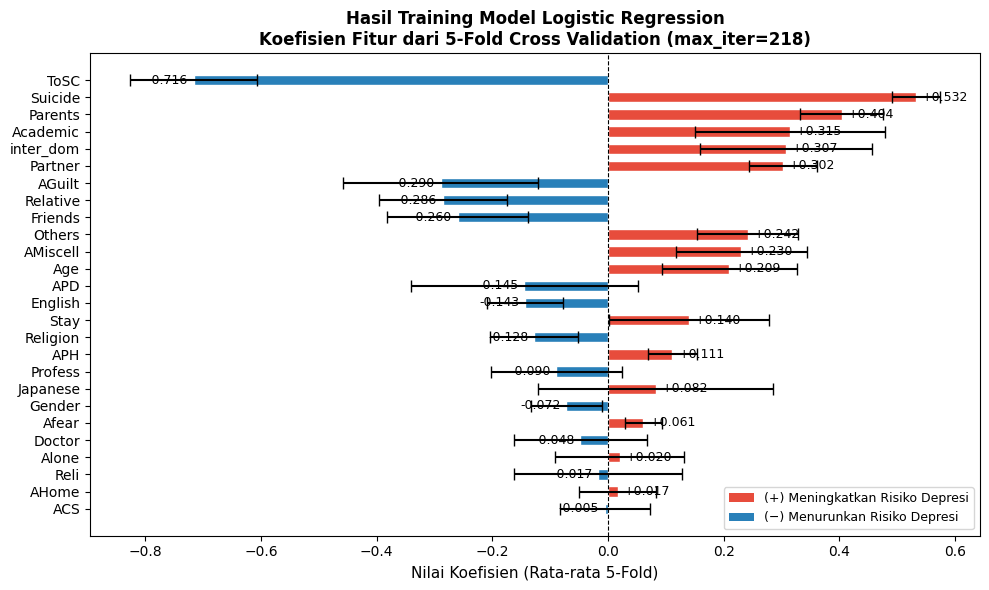


Gambar disimpan sebagai: koefisien_LR_training.png


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ==========================================================
# 1. Inisialisasi model dengan "Bobot" Titik Plateau
# ==========================================================

lr_model  = LogisticRegression(max_iter=217, random_state=42)
svm_model = SVC(probability=True, max_iter=-1, random_state=42)
rf_model  = RandomForestClassifier(n_estimators=197, random_state=42)
xgb_model = XGBClassifier(n_estimators=2003, learning_rate=0.05, eval_metric='logloss', random_state=42)

base_estimators = [
    ('lr',  lr_model),
    ('svm', svm_model),
    ('rf',  rf_model),
    ('xgb', xgb_model)
]

models = {
    "SVM"                    : svm_model,
    "Random Forest"          : rf_model,
    "Logistic Regression"    : lr_model,
    "XGBoost"                : xgb_model,
    "Ensemble_Majority_Voting": VotingClassifier(estimators=base_estimators, voting='hard'),
    "Ensemble_Stacking"      : StackingClassifier(
                                    estimators=base_estimators,
                                    final_estimator=LogisticRegression(),
                                    cv=5
                               )
}

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

all_model_scores = {}

# ← TAMBAHAN: variabel untuk menampung koefisien LR per fold
lr_coefs_per_fold = []

# ==========================================================
# 4. Loop untuk setiap model
# ==========================================================

for model_name, model in models.items():
    print(f"--- Menjalankan Testing K-Fold: {model_name} ---")

    fold_num = 1
    scores   = []

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        model.fit(X_train_scaled, y_train)

        # ← TAMBAHAN: ambil koefisien khusus saat model LR selesai dilatih
        if model_name == "Logistic Regression":
            lr_coefs_per_fold.append(model.coef_[0].copy())
            print(f"  [Koefisien Fold {fold_num} berhasil disimpan]")

        predictions = model.predict(X_test_scaled)
        accuracy    = accuracy_score(y_test, predictions)

        print(f"Fold {fold_num} Accuracy: {accuracy:.4f}")
        scores.append(accuracy)
        fold_num += 1

    all_model_scores[model_name] = scores
    print(f"Rata-rata Akurasi Akhir {model_name}: {np.mean(scores):.4f}")
    print("-" * 40 + "\n")


# ==========================================================
# TAMBAHAN: TAMPILKAN HASIL TRAINING MODEL LR
# (Koefisien Fitur — untuk keperluan Revisi Tesis BAB IV)
# ==========================================================

feature_names = list(X.columns)
coef_matrix   = np.array(lr_coefs_per_fold)  # shape: (5 fold, n_fitur)
mean_coefs    = coef_matrix.mean(axis=0)
std_coefs     = coef_matrix.std(axis=0)

# --- Tabel koefisien per fold ---
df_per_fold = pd.DataFrame(
    coef_matrix,
    columns=feature_names,
    index=[f'Fold {i}' for i in range(1, 6)]
)
df_per_fold.loc['Rata-rata'] = mean_coefs
df_per_fold.loc['Std. Dev']  = std_coefs

print("=" * 60)
print("TABEL: KOEFISIEN FITUR MODEL LR PER FOLD")
print("=" * 60)
print(df_per_fold.round(4).to_string())

# --- Tabel ringkas untuk tesis ---
df_summary = pd.DataFrame({
    'Fitur'              : feature_names,
    'Koefisien Rata-rata': mean_coefs.round(4),
    'Std. Dev'           : std_coefs.round(4),
    'Arah Pengaruh'      : ['(+) Meningkatkan Risiko Depresi' if c > 0
                             else '(−) Menurunkan Risiko Depresi'
                             for c in mean_coefs]
}).sort_values('Koefisien Rata-rata', key=abs, ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("TABEL RINGKAS: RATA-RATA KOEFISIEN (untuk Tesis)")
print("=" * 60)
print(df_summary.to_string(index=False))

# --- Visualisasi horizontal bar chart ---
df_plot = df_summary.copy()
colors  = ['#e74c3c' if c > 0 else '#2980b9'
           for c in df_plot['Koefisien Rata-rata']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    df_plot['Fitur'],
    df_plot['Koefisien Rata-rata'],
    xerr=df_plot['Std. Dev'],
    color=colors,
    edgecolor='white',
    capsize=4,
    height=0.6
)

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Nilai Koefisien (Rata-rata 5-Fold)', fontsize=11)
ax.set_title(
    'Hasil Training Model Logistic Regression\n'
    'Koefisien Fitur dari 5-Fold Cross Validation (max_iter=218)',
    fontsize=12, fontweight='bold'
)
ax.invert_yaxis()

for bar, val in zip(bars, df_plot['Koefisien Rata-rata']):
    ax.text(
        val + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

legend_elements = [
    Patch(facecolor='#e74c3c', label='(+) Meningkatkan Risiko Depresi'),
    Patch(facecolor='#2980b9', label='(−) Menurunkan Risiko Depresi')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('koefisien_LR_training.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nGambar disimpan sebagai: koefisien_LR_training.png")

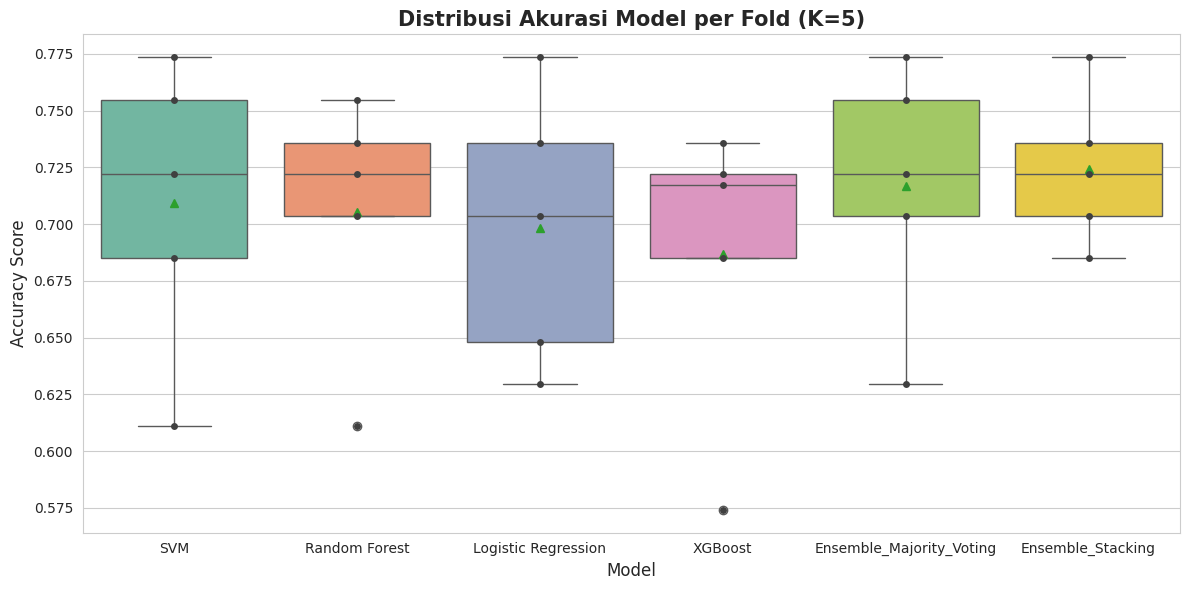

In [ ]:
# ==========================================
# VISUALISASI 1: BOXPLOT HASIL K-FOLD
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

# Konversi skor ke DataFrame
df_boxplot = pd.DataFrame(all_model_scores)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Membuat Boxplot
ax = sns.boxplot(data=df_boxplot, palette="Set2", showmeans=True)

# Menambahkan titik data asli (swarmplot) agar lebih detail
sns.swarmplot(data=df_boxplot, color=".25", size=5)

plt.title('Distribusi Akurasi Model per Fold (K=5)', fontsize=15, fontweight='bold')
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats
from itertools import combinations
import numpy as np

# 1. Definisikan daftar model (Tanpa Soft Voting)
base_models = ["SVM", "Random Forest", "Logistic Regression", "XGBoost"]
ensemble_models = ["Ensemble_Majority_Voting", "Ensemble_Stacking"]

print("="*65)
print("ANALISIS SIGNIFIKANSI STATISTIK (PAIRED T-TEST)")
print("Alpha: 0.05 | Skema: 5-Fold Cross Validation")
print("="*65 + "\n")

# --- BAGIAN A: PERBANDINGAN ANTAR MODEL TUNGGAL ---
print("--- [A] PERBANDINGAN ANTAR MODEL TUNGGAL ---")
for m1, m2 in combinations(base_models, 2):
    scores1 = all_model_scores[m1]
    scores2 = all_model_scores[m2]

    # Paired T-Test
    t_stat, p_value = stats.ttest_rel(scores1, scores2)

    print(f"Perbandingan: {m1} vs {m2}")
    print(f"T-Statistic : {t_stat:.4f} | P-Value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"Kesimpulan  : BERBEDA SIGNIFIKAN.")
    else:
        print(f"Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).")
    print("-" * 45)

print("\n" + "="*55 + "\n")

# --- BAGIAN B: PERBANDINGAN ENSEMBLE VS MODEL TUNGGAL ---
print("--- [B] PERBANDINGAN ENSEMBLE VS MODEL TUNGGAL ---")
for ens_name in ensemble_models:
    print(f"##### Analisis untuk: {ens_name} #####")
    for base_name in base_models:
        scores_ens = all_model_scores[ens_name]
        scores_base = all_model_scores[base_name]

        t_stat, p_value = stats.ttest_rel(scores_ens, scores_base)

        print(f"Komparasi  : {ens_name} vs {base_name}")
        print(f"P-Value    : {p_value:.4f}")

        if p_value < 0.05:
            res = "LEBIH BAIK & SIGNIFIKAN" if t_stat > 0 else "LEBIH RENDAH & SIGNIFIKAN"
            print(f"Hasil      : {res}")
        else:
            print(f"Hasil      : Performa Setara (TIDAK SIGNIFIKAN).")
        print("-" * 45)
    print("\n")

# --- BAGIAN C: KOMPARASI INTERNAL ENSEMBLE ---
print("--- [C] KOMPARASI STACKING VS MAJORITY VOTING ---")
t_final, p_final = stats.ttest_rel(all_model_scores["Ensemble_Stacking"], all_model_scores["Ensemble_Majority_Voting"])

print(f"P-Value: {p_final:.4f}")
if p_final < 0.05:
    print("Hasil  : Stacking memberikan peningkatan performa yang SIGNIFIKAN.")
else:
    print("Hasil  : Stacking dan Majority Voting memiliki performa SETARA.")
print("="*65)

ANALISIS SIGNIFIKANSI STATISTIK (PAIRED T-TEST)
Alpha: 0.05 | Skema: 5-Fold Cross Validation

--- [A] PERBANDINGAN ANTAR MODEL TUNGGAL ---
Perbandingan: SVM vs Random Forest
T-Statistic : 0.3544 | P-Value: 0.7410
Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).
---------------------------------------------
Perbandingan: SVM vs Logistic Regression
T-Statistic : 0.3701 | P-Value: 0.7300
Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).
---------------------------------------------
Perbandingan: SVM vs XGBoost
T-Statistic : 1.5117 | P-Value: 0.2052
Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).
---------------------------------------------
Perbandingan: Random Forest vs Logistic Regression
T-Statistic : 0.2342 | P-Value: 0.8263
Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).
---------------------------------------------
Perbandingan: Random Forest vs XGBoost
T-Statistic : 3.1858 | P-Value: 0.0333
Kesimpulan  : BERBEDA SIGNIFIKAN.
---------------------------------------------
Perband

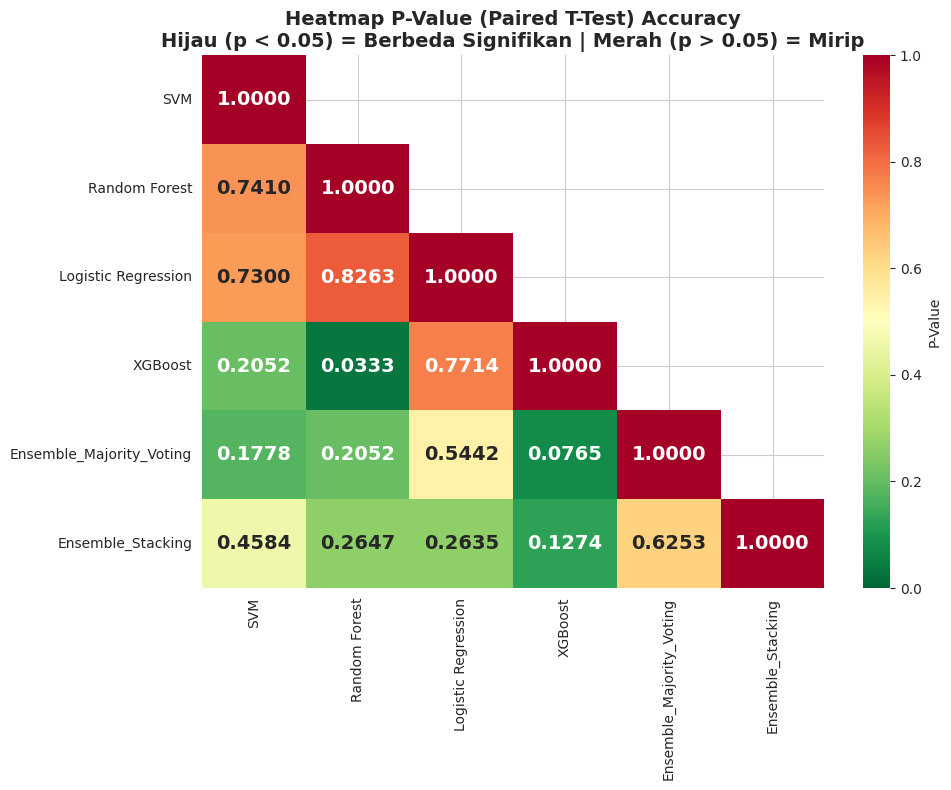

In [ ]:
# ==========================================
# VISUALISASI 2: HEATMAP SIGNIFIKANSI (P-VALUE) - UPDATED COLORS
# ==========================================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Siapkan matriks kosong untuk menyimpan P-Value
model_names = list(all_model_scores.keys())
n = len(model_names)
p_matrix = np.zeros((n, n))

# 2. Isi matriks dengan P-Value dari hasil T-Test
for i in range(n):
    for j in range(n):
        if i == j:
            p_matrix[i, j] = 1.0 # Perbandingan dengan diri sendiri (P-Value pasti 1)
        else:
            scores_a = all_model_scores[model_names[i]]
            scores_b = all_model_scores[model_names[j]]
            _, p_val = stats.ttest_rel(scores_a, scores_b)
            p_matrix[i, j] = p_val

# 3. Buat Heatmap
plt.figure(figsize=(10, 8))

# Mask untuk menyembunyikan bagian atas (karena matriksnya simetris)
mask = np.triu(np.ones_like(p_matrix, dtype=bool), k=1)

# Menggunakan 'RdYlGn_r' agar:
# Nilai rendah (p < 0.05) -> HIJAU (Signifikan)
# Nilai tinggi (p > 0.05) -> MERAH (Tidak Signifikan)
sns.heatmap(p_matrix, annot=True, fmt=".4f", cmap="RdYlGn_r",
            xticklabels=model_names, yticklabels=model_names,
            mask=mask, vmin=0, vmax=1,annot_kws={"size": 14, "weight": "bold"}, # BESARKAN ANGKA DI DALAM KOTAK
            cbar_kws={'label': 'P-Value'})

plt.title('Heatmap P-Value (Paired T-Test) Accuracy\nHijau (p < 0.05) = Berbeda Signifikan | Merah (p > 0.05) = Mirip',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Khusus untuk melihat isi Fold 1 — Logistic Regression
from sklearn.metrics import confusion_matrix

skf_check = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler_check = StandardScaler()

for fold_num, (train_index, test_index) in enumerate(skf_check.split(X, y), start=1):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    X_train_scaled = scaler_check.fit_transform(X_train)
    X_test_scaled  = scaler_check.transform(X_test)

    model_check = LogisticRegression(max_iter=217, random_state=42)
    model_check.fit(X_train_scaled, y_train)
    predictions = model_check.predict(X_test_scaled)

    # Buat tabel bukti prediksi per data
    hasil = X_test.copy()
    hasil['Label_Asli']   = y_test.values          # jawaban benar
    hasil['Prediksi']     = predictions             # tebakan model
    hasil['Kategori'] = ''

    for i in range(len(hasil)):
        asli = hasil['Label_Asli'].iloc[i]
        pred = hasil['Prediksi'].iloc[i]
        if   asli == 1 and pred == 1: hasil['Kategori'].iloc[i] = 'TP'
        elif asli == 0 and pred == 0: hasil['Kategori'].iloc[i] = 'TN'
        elif asli == 0 and pred == 1: hasil['Kategori'].iloc[i] = 'FP'
        elif asli == 1 and pred == 0: hasil['Kategori'].iloc[i] = 'FN'

    cm = confusion_matrix(y_test, predictions)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n===== FOLD {fold_num} =====")
    print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
    print(f"Jumlah data test: {len(y_test)}")
    print(hasil[['Label_Asli','Prediksi','Kategori']].to_string())

    if fold_num == 1:
        break  # hapus baris ini kalau mau lihat semua fold


===== FOLD 1 =====
TP=8, TN=30, FP=5, FN=11
Jumlah data test: 54
     Label_Asli  Prediksi Kategori
8             1         0       FN
10            0         0       TN
17            0         0       TN
19            0         0       TN
23            0         0       TN
26            1         0       FN
27            0         0       TN
32            0         0       TN
33            0         0       TN
35            1         1       TP
36            0         0       TN
38            1         1       TP
40            0         0       TN
42            0         0       TN
43            1         0       FN
58            1         0       FN
60            0         0       TN
68            0         0       TN
70            1         0       FN
82            0         0       TN
90            0         0       TN
97            0         0       TN
98            0         0       TN
102           0         1       FP
103           0         0       TN
106           1         

/tmp/ipykernel_999/534560160.py:31: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  elif asli == 1 and pred == 0: hasil['Kategori'].iloc[i] = 'FN'
/tmp/ipykernel_999/534560160.py:31: SettingWithCopyWarning: 
A value is trying to be set on a co

# **2. PRECISION**

In [ ]:
from sklearn.metrics import precision_score
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import VotingClassifier, StackingClassifier # Tambah Stacking
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Kamus untuk menyimpan skor presisi tiap model untuk nantinya di-Uji T
all_model_precision = {}

# ==========================================================
# 1. Inisialisasi Model dengan "Bobot" Titik Plateau Anda
# ==========================================================
lr_model = LogisticRegression(max_iter=217, random_state=42)
svm_model = SVC(probability=True, max_iter=-1, random_state=42)
rf_model = RandomForestClassifier(n_estimators=197, random_state=42)
xgb_model = XGBClassifier(n_estimators=2003, learning_rate=0.05, eval_metric='logloss', random_state=42)

# Daftar estimator dasar untuk Ensemble
base_estimators = [
    ('lr', lr_model),
    ('svm', svm_model),
    ('rf', rf_model),
    ('xgb', xgb_model)
]

# 2. Definisikan semua model (Individu + 2 Jenis Ensemble)
models = {
    "SVM": svm_model,
    "Random Forest": rf_model,
    "Logistic Regression": lr_model,
    "XGBoost": xgb_model,
    "Ensemble_Majority_Voting": VotingClassifier(
        estimators=base_estimators,
        voting='hard'
    ),
    "Ensemble_Stacking": StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(),
        cv=5
    )
}

# 3. Konfigurasi K-Fold (Gunakan 5-Fold sesuai permintaan terakhir Anda)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

# 4. Loop Proses Evaluasi
for model_name, model in models.items():
    print(f"--- Menjalankan 5-Fold: {model_name} (Metrik: Precision) ---")
    print(f"Konfigurasi: Optimal Plateau Points")

    fold_num = 1
    scores = []

    for train_index, test_index in skf.split(X, y):
        # Split Data
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # SCALING DALAM FOLD (Sangat Penting untuk SVM & LR)
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Training
        model.fit(X_train_scaled, y_train)

        # Prediksi
        predictions = model.predict(X_test_scaled)

        # menampilkan metrik
        cm = confusion_matrix(y_test, predictions)
        tn, fp, fn, tp = cm.ravel()
        print(f"  Fold {fold_num} → TP={tp}, TN={tn}, FP={fp}, FN={fn}")

        # Hitung Precision (1 = Depresi, 0 = Tidak)
        precision = precision_score(y_test, predictions, average='binary', zero_division=0)

        print(f"Fold {fold_num} Precision: {precision:.4f}")
        scores.append(precision)
        fold_num += 1

    all_model_precision[model_name] = scores
    print(f"Rata-rata Precision {model_name}: {np.mean(scores):.4f}")
    print("-" * 45 + "\n")

--- Menjalankan 5-Fold: SVM (Metrik: Precision) ---
Konfigurasi: Optimal Plateau Points
  Fold 1 → TP=4, TN=29, FP=6, FN=15
Fold 1 Precision: 0.4000
  Fold 2 → TP=7, TN=30, FP=5, FN=12
Fold 2 Precision: 0.5833
  Fold 3 → TP=10, TN=29, FP=5, FN=10
Fold 3 Precision: 0.6667
  Fold 4 → TP=10, TN=31, FP=3, FN=9
Fold 4 Precision: 0.7692
  Fold 5 → TP=9, TN=31, FP=3, FN=10
Fold 5 Precision: 0.7500
Rata-rata Precision SVM: 0.6338
---------------------------------------------

--- Menjalankan 5-Fold: Random Forest (Metrik: Precision) ---
Konfigurasi: Optimal Plateau Points
  Fold 1 → TP=5, TN=28, FP=7, FN=14
Fold 1 Precision: 0.4167
  Fold 2 → TP=8, TN=31, FP=4, FN=11
Fold 2 Precision: 0.6667
  Fold 3 → TP=10, TN=28, FP=6, FN=10
Fold 3 Precision: 0.6250
  Fold 4 → TP=10, TN=30, FP=4, FN=9
Fold 4 Precision: 0.7143
  Fold 5 → TP=8, TN=31, FP=3, FN=11
Fold 5 Precision: 0.7273
Rata-rata Precision Random Forest: 0.6300
---------------------------------------------

--- Menjalankan 5-Fold: Logistic R

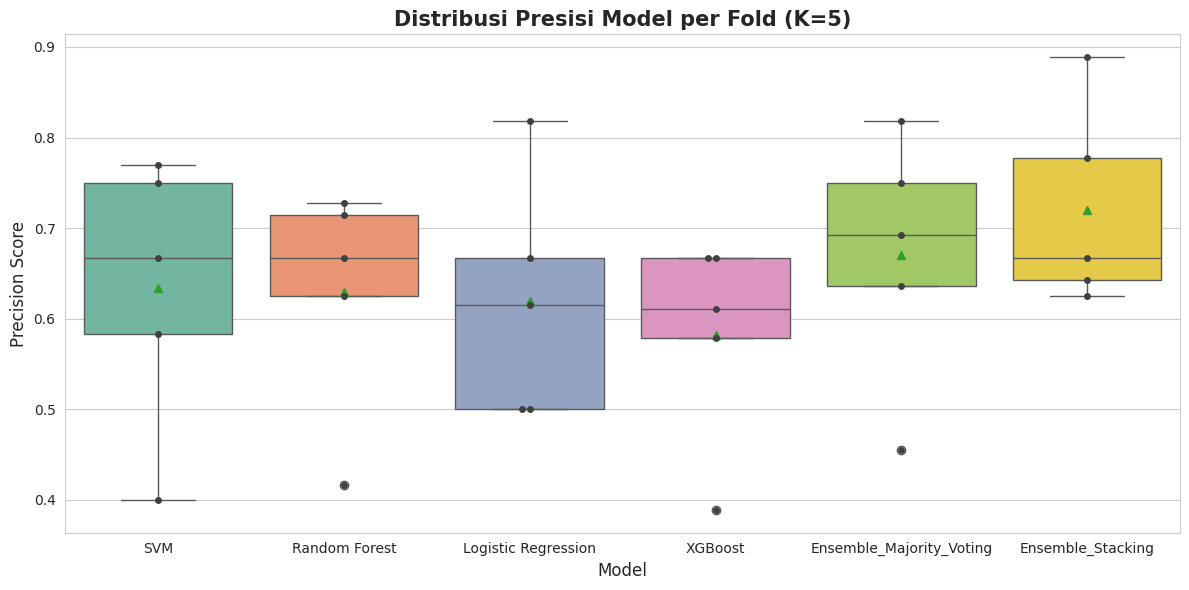

In [ ]:
# ==========================================
# VISUALISASI 1: BOXPLOT HASIL K-FOLD (PRECISION)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

# Konversi skor ke DataFrame
df_boxplot = pd.DataFrame(all_model_precision)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Membuat Boxplot
ax = sns.boxplot(data=df_boxplot, palette="Set2", showmeans=True)

# Menambahkan titik data asli (swarmplot) agar lebih detail
sns.swarmplot(data=df_boxplot, color=".25", size=5)

plt.title('Distribusi Presisi Model per Fold (K=5)', fontsize=15, fontweight='bold')
plt.ylabel('Precision Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

Penjelasan Penting: Parameter average
Saat menggunakan precision_score, Anda harus memilih metode rata-rata jika data Anda bersifat Multiclass (lebih dari dua label, contoh: kelas A, B, dan C):
* average='binary': Digunakan hanya jika target Anda cuma 0 dan 1 (Default).
* average='macro': Menghitung presisi untuk setiap kelas, lalu merata-ratakannya secara murni. (Paling sering digunakan jika ingin memperlakukan semua kelas setara).
* average='weighted': Menghitung presisi setiap kelas, lalu merata-ratakannya berdasarkan jumlah anggota setiap kelas. (Bagus jika dataset Anda tidak seimbang/imbalanced).
* average='micro': Menghitung total positif asli dan total positif prediksi secara global.

In [ ]:
from scipy import stats
from itertools import combinations

# 1. Tentukan daftar kelompok model
base_models = ["SVM", "Random Forest", "Logistic Regression", "XGBoost"]
# Hanya Hard Voting dan Stacking sesuai permintaan
ensemble_models = ["Ensemble_Majority_Voting", "Ensemble_Stacking"]

print("="*70)
print("ANALISIS SIGNIFIKANSI STATISTIK: PRECISION (PAIRED T-TEST)")
print("Skema: 5-Fold Cross Validation | Alpha: 0.05")
print("="*70 + "\n")

# --- BAGIAN A: PERBANDINGAN ANTAR MODEL TUNGGAL (Untuk BAB IV) ---
print("--- [A] PERBANDINGAN ANTAR MODEL TUNGGAL ---")
for m1, m2 in combinations(base_models, 2):
    scores1 = all_model_precision[m1]
    scores2 = all_model_precision[m2]

    t_stat, p_value = stats.ttest_rel(scores1, scores2)

    print(f"Perbandingan: {m1} vs {m2}")
    print(f"T-Statistic: {t_stat:.4f} | P-Value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"Kesimpulan : BERBEDA SIGNIFIKAN.")
    else:
        print(f"Kesimpulan : Performa Setara (TIDAK SIGNIFIKAN).")
    print("-" * 40)

print("\n" + "="*60 + "\n")

# --- BAGIAN B: PERBANDINGAN ENSEMBLE VS MODEL TUNGGAL (Untuk BAB V) ---
print("--- [B] PERBANDINGAN ENSEMBLE VS MODEL TUNGGAL ---")
for ens_name in ensemble_models:
    print(f"##### ANALISIS UNTUK: {ens_name} #####")
    for base_name in base_models:
        scores_ens = all_model_precision[ens_name]
        scores_base = all_model_precision[base_name]

        t_stat, p_value = stats.ttest_rel(scores_ens, scores_base)

        print(f"Komparasi  : {ens_name} vs {base_name}")
        print(f"T-Statistic: {t_stat:.4f} | P-Value: {p_value:.4f}")

        if p_value < 0.05:
            better = "UNGGUL & " if t_stat > 0 else "LEBIH RENDAH & "
            print(f"Hasil      : {better}BERBEDA SIGNIFIKAN secara statistik.")
        else:
            print("Hasil      : Performa Setara (TIDAK SIGNIFIKAN).")
        print("-" * 40)
    print("\n")

# --- BAGIAN C: KOMPARASI INTERNAL ENSEMBLE (STACKING VS VOTING) ---
print("--- [C] KOMPARASI STACKING VS HARD VOTING ---")
scores_stack = all_model_precision["Ensemble_Stacking"]
scores_vote = all_model_precision["Ensemble_Majority_Voting"]

t_final, p_final = stats.ttest_rel(scores_stack, scores_vote)

print(f"Perbandingan: Ensemble Stacking vs Hard Voting")
print(f"T-Statistic : {t_final:.4f}")
print(f"P-Value     : {p_final:.4f}")

if p_final < 0.05:
    print("Kesimpulan  : Stacking memberikan peningkatan Precision yang SIGNIFIKAN.")
else:
    print("Kesimpulan  : Stacking dan Hard Voting memiliki performa SETARA secara statistik.")
print("="*70)

ANALISIS SIGNIFIKANSI STATISTIK: PRECISION (PAIRED T-TEST)
Skema: 5-Fold Cross Validation | Alpha: 0.05

--- [A] PERBANDINGAN ANTAR MODEL TUNGGAL ---
Perbandingan: SVM vs Random Forest
T-Statistic: 0.1552 | P-Value: 0.8842
Kesimpulan : Performa Setara (TIDAK SIGNIFIKAN).
----------------------------------------
Perbandingan: SVM vs Logistic Regression
T-Statistic: 0.2063 | P-Value: 0.8466
Kesimpulan : Performa Setara (TIDAK SIGNIFIKAN).
----------------------------------------
Perbandingan: SVM vs XGBoost
T-Statistic: 1.2976 | P-Value: 0.2642
Kesimpulan : Performa Setara (TIDAK SIGNIFIKAN).
----------------------------------------
Perbandingan: Random Forest vs Logistic Regression
T-Statistic: 0.1427 | P-Value: 0.8934
Kesimpulan : Performa Setara (TIDAK SIGNIFIKAN).
----------------------------------------
Perbandingan: Random Forest vs XGBoost
T-Statistic: 2.4770 | P-Value: 0.0684
Kesimpulan : Performa Setara (TIDAK SIGNIFIKAN).
----------------------------------------
Perbandingan: L

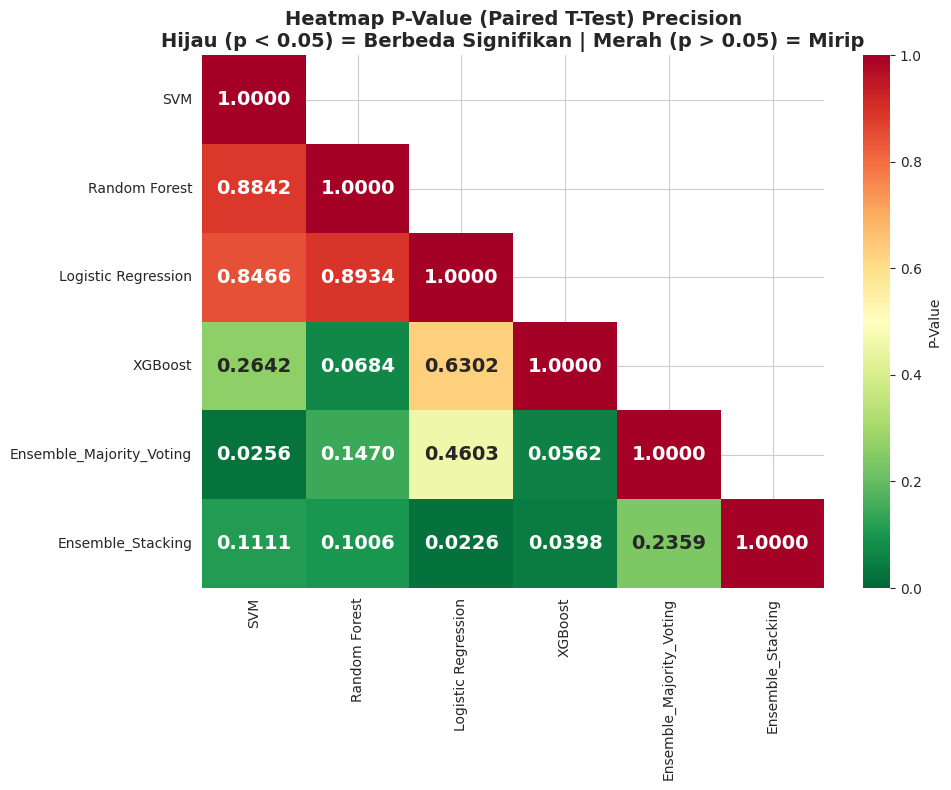

In [ ]:
# ==========================================
# VISUALISASI 2: HEATMAP SIGNIFIKANSI (P-VALUE) - PRECISION
# ==========================================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Siapkan matriks kosong untuk menyimpan P-Value
model_names = list(all_model_precision.keys())
n = len(model_names)
p_matrix = np.zeros((n, n))

# 2. Isi matriks dengan P-Value dari hasil T-Test
for i in range(n):
    for j in range(n):
        if i == j:
            p_matrix[i, j] = 1.0 # Perbandingan dengan diri sendiri (P-Value pasti 1)
        else:
            scores_a = all_model_precision[model_names[i]]
            scores_b = all_model_precision[model_names[j]]
            _, p_val = stats.ttest_rel(scores_a, scores_b)
            p_matrix[i, j] = p_val

# 3. Buat Heatmap
plt.figure(figsize=(10, 8))

# Mask untuk menyembunyikan bagian atas (karena matriksnya simetris)
mask = np.triu(np.ones_like(p_matrix, dtype=bool), k=1)

# Menggunakan 'RdYlGn_r' agar:
# Nilai rendah (p < 0.05) -> HIJAU (Signifikan)
# Nilai tinggi (p > 0.05) -> MERAH (Tidak Signifikan)
sns.heatmap(p_matrix, annot=True, fmt=".4f", cmap="RdYlGn_r",
            xticklabels=model_names, yticklabels=model_names,
            mask=mask, vmin=0, vmax=1,annot_kws={"size": 14, "weight": "bold"}, # BESARKAN ANGKA DI DALAM KOTAK
            cbar_kws={'label': 'P-Value'})

plt.title('Heatmap P-Value (Paired T-Test) Precision\nHijau (p < 0.05) = Berbeda Signifikan | Merah (p > 0.05) = Mirip',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **3. RECALL**

In [ ]:
from sklearn.metrics import recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import VotingClassifier, StackingClassifier # Tambah Stacking
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Kamus untuk menyimpan skor Recall tiap model untuk nantinya di-Uji T
all_model_recall = {}

# ==========================================================
# 1. Inisialisasi Model dengan "Bobot" Titik Plateau Anda
# ==========================================================
lr_model = LogisticRegression(max_iter=217, random_state=42)
svm_model = SVC(probability=True, max_iter=-1, random_state=42)
rf_model = RandomForestClassifier(n_estimators=197, random_state=42)
xgb_model = XGBClassifier(n_estimators=2003, learning_rate=0.05, eval_metric='logloss', random_state=42)

# Daftar estimator dasar untuk Ensemble
base_estimators = [
    ('lr', lr_model),
    ('svm', svm_model),
    ('rf', rf_model),
    ('xgb', xgb_model)
]

# 2. Definisikan semua model (Individu + 3 Jenis Ensemble)
models = {
    "SVM": svm_model,
    "Random Forest": rf_model,
    "Logistic Regression": lr_model,
    "XGBoost": xgb_model,
    "Ensemble_Majority_Voting": VotingClassifier(
        estimators=base_estimators,
        voting='hard'
    ),
    "Ensemble_Stacking": StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(), # Meta-learner
        cv=5
    )
}

# 3. Konfigurasi 5-Fold & Scaler
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

# 4. Proses Loop 5-Fold
for model_name, model in models.items():
    print(f"--- Menjalankan 5-Fold: {model_name} (Metrik: Recall) ---")
    print(f"Konfigurasi: Optimal Plateau Points")

    fold_num = 1
    scores = []

    for train_index, test_index in skf.split(X, y):
        # Membagi data secara manual per fold
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # PROSES SCALING DALAM FOLD (Wajib agar valid secara akademik)
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Melatih model menggunakan data yang sudah di-scale
        model.fit(X_train_scaled, y_train)

        # Melakukan Prediksi
        predictions = model.predict(X_test_scaled)

         # menampilkan metrik
        cm = confusion_matrix(y_test, predictions)
        tn, fp, fn, tp = cm.ravel()
        print(f"  Fold {fold_num} → TP={tp}, TN={tn}, FP={fp}, FN={fn}")

        # MENGHITUNG RECALL
        # average='binary' fokus pada seberapa banyak kasus depresi yang berhasil ditemukan
        recall = recall_score(y_test, predictions, average='binary')

        print(f"Fold {fold_num} Recall: {recall:.4f}")
        scores.append(recall)
        fold_num += 1

    # Simpan hasil skor fold ke dictionary untuk Uji T nanti
    all_model_recall[model_name] = scores

    print(f"Rata-rata Recall {model_name}: {np.mean(scores):.4f}")
    print("-" * 45 + "\n")

--- Menjalankan 5-Fold: SVM (Metrik: Recall) ---
Konfigurasi: Optimal Plateau Points
  Fold 1 → TP=4, TN=29, FP=6, FN=15
Fold 1 Recall: 0.2105
  Fold 2 → TP=7, TN=30, FP=5, FN=12
Fold 2 Recall: 0.3684
  Fold 3 → TP=10, TN=29, FP=5, FN=10
Fold 3 Recall: 0.5000
  Fold 4 → TP=10, TN=31, FP=3, FN=9
Fold 4 Recall: 0.5263
  Fold 5 → TP=9, TN=31, FP=3, FN=10
Fold 5 Recall: 0.4737
Rata-rata Recall SVM: 0.4158
---------------------------------------------

--- Menjalankan 5-Fold: Random Forest (Metrik: Recall) ---
Konfigurasi: Optimal Plateau Points
  Fold 1 → TP=5, TN=28, FP=7, FN=14
Fold 1 Recall: 0.2632
  Fold 2 → TP=8, TN=31, FP=4, FN=11
Fold 2 Recall: 0.4211
  Fold 3 → TP=10, TN=28, FP=6, FN=10
Fold 3 Recall: 0.5000
  Fold 4 → TP=10, TN=30, FP=4, FN=9
Fold 4 Recall: 0.5263
  Fold 5 → TP=8, TN=31, FP=3, FN=11
Fold 5 Recall: 0.4211
Rata-rata Recall Random Forest: 0.4263
---------------------------------------------

--- Menjalankan 5-Fold: Logistic Regression (Metrik: Recall) ---
Konfigurasi

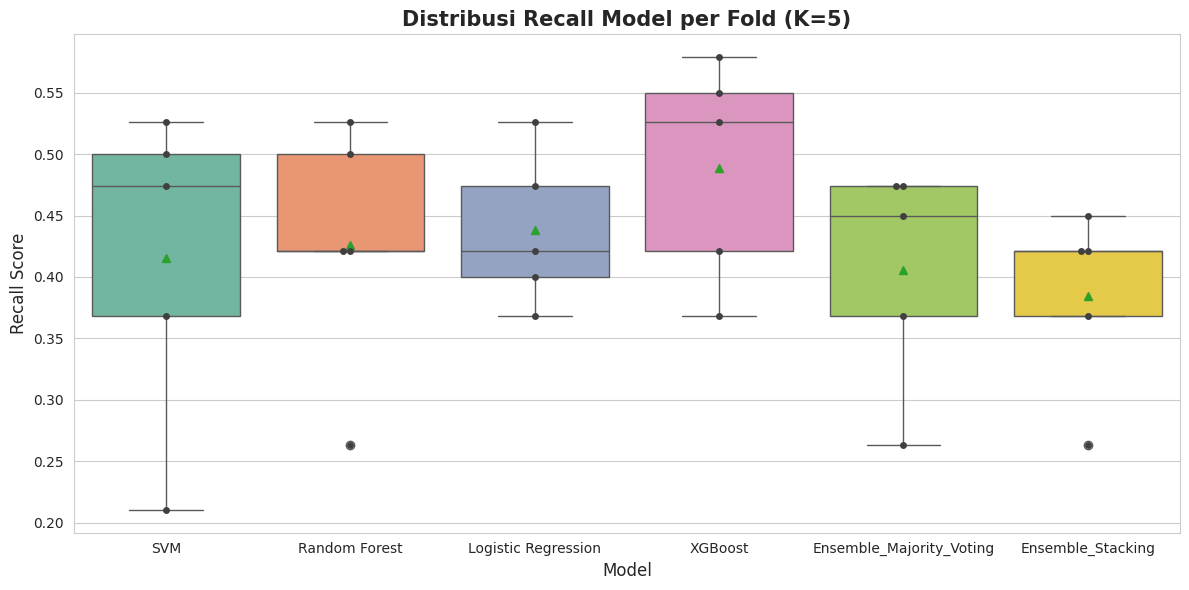

In [ ]:
# ==========================================
# VISUALISASI 1: BOXPLOT HASIL K-FOLD (RECALL)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

# Konversi skor ke DataFrame
df_boxplot = pd.DataFrame(all_model_recall)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Membuat Boxplot
ax = sns.boxplot(data=df_boxplot, palette="Set2", showmeans=True)

# Menambahkan titik data asli (swarmplot) agar lebih detail
sns.swarmplot(data=df_boxplot, color=".25", size=5)

plt.title('Distribusi Recall Model per Fold (K=5)', fontsize=15, fontweight='bold')
plt.ylabel('Recall Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats
from itertools import combinations

# 1. Daftar model yang akan dibandingkan (Soft Voting Dihapus)
base_models = ["SVM", "Random Forest", "Logistic Regression", "XGBoost"]
ensemble_models = ["Ensemble_Majority_Voting", "Ensemble_Stacking"]

print("="*75)
print("ANALISIS SIGNIFIKANSI STATISTIK: RECALL / SENSITIVITY (PAIRED T-TEST)")
print("Skema: 5-Fold Cross Validation | Alpha: 0.05")
print("="*75 + "\n")

# --- BAGIAN A: PERBANDINGAN ANTAR MODEL TUNGGAL (Untuk BAB IV) ---
print("--- [A] PERBANDINGAN ANTAR MODEL TUNGGAL ---")
for m1, m2 in combinations(base_models, 2):
    scores1 = all_model_recall[m1]
    scores2 = all_model_recall[m2]

    t_stat, p_value = stats.ttest_rel(scores1, scores2)

    print(f"Perbandingan: {m1} vs {m2}")
    print(f"T-Statistic : {t_stat:.4f} | P-Value: {p_value:.4f}")
    if p_value < 0.05:
        better_model = m1 if t_stat > 0 else m2
        print(f"Kesimpulan  : BERBEDA SIGNIFIKAN ({better_model} lebih unggul).")
    else:
        print("Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).")
    print("-" * 50)

print("\n" + "="*65 + "\n")

# --- BAGIAN B: PERBANDINGAN ENSEMBLE VS MODEL TUNGGAL (Untuk BAB V) ---
print("--- [B] PERBANDINGAN ENSEMBLE VS MODEL TUNGGAL ---")
for ensemble_name in ensemble_models:
    print(f"##### ANALISIS UNTUK: {ensemble_name} #####")
    for base_name in base_models:
        scores_ensemble = all_model_recall[ensemble_name]
        scores_base = all_model_recall[base_name]

        t_stat, p_value = stats.ttest_rel(scores_ensemble, scores_base)

        print(f"Komparasi   : {ensemble_name} vs {base_name}")
        print(f"T-Statistic : {t_stat:.4f} | P-Value: {p_value:.4f}")

        if p_value < 0.05:
            if t_stat > 0:
                print("Kesimpulan  : Ensemble UNGGUL & BERBEDA SIGNIFIKAN.")
            else:
                print("Kesimpulan  : BERBEDA SIGNIFIKAN (Model Tunggal justru lebih tinggi).")
        else:
            print("Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).")
        print("-" * 50)
    print("\n")

# --- BAGIAN C: KOMPARASI INTERNAL ENSEMBLE (STACKING VS VOTING) ---
print("--- [C] KOMPARASI STACKING VS MAJORITY VOTING ---")
scores_stack = all_model_recall["Ensemble_Stacking"]
scores_vote = all_model_recall["Ensemble_Majority_Voting"]

t_final, p_final = stats.ttest_rel(scores_stack, scores_vote)

print(f"Perbandingan: Ensemble Stacking vs Majority Voting")
print(f"T-Statistic : {t_final:.4f} | P-Value: {p_final:.4f}")

if p_final < 0.05:
    print("Kesimpulan  : Terdapat perbedaan jangkauan deteksi yang SIGNIFIKAN.")
else:
    print("Kesimpulan  : Stacking dan Majority Voting memiliki daya jangkau deteksi yang SETARA.")
print("="*75)

ANALISIS SIGNIFIKANSI STATISTIK: RECALL / SENSITIVITY (PAIRED T-TEST)
Skema: 5-Fold Cross Validation | Alpha: 0.05

--- [A] PERBANDINGAN ANTAR MODEL TUNGGAL ---
Perbandingan: SVM vs Random Forest
T-Statistic : -0.5345 | P-Value: 0.6213
Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).
--------------------------------------------------
Perbandingan: SVM vs Logistic Regression
T-Statistic : -0.4126 | P-Value: 0.7011
Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).
--------------------------------------------------
Perbandingan: SVM vs XGBoost
T-Statistic : -2.7151 | P-Value: 0.0533
Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).
--------------------------------------------------
Perbandingan: Random Forest vs Logistic Regression
T-Statistic : -0.2296 | P-Value: 0.8297
Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).
--------------------------------------------------
Perbandingan: Random Forest vs XGBoost
T-Statistic : -2.0375 | P-Value: 0.1113
Kesimpulan  : Performa Setara (TIDAK SIG

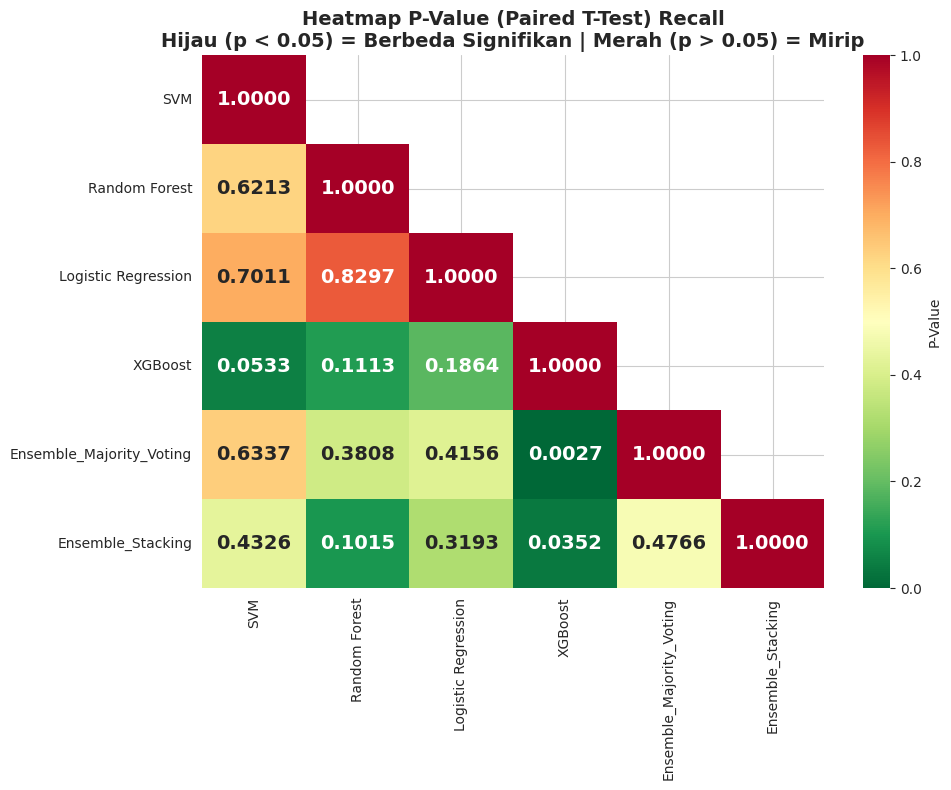

In [ ]:
# ==========================================
# VISUALISASI 2: HEATMAP SIGNIFIKANSI (P-VALUE) - RECALL
# ==========================================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Siapkan matriks kosong untuk menyimpan P-Value
model_names = list(all_model_recall.keys())
n = len(model_names)
p_matrix = np.zeros((n, n))

# 2. Isi matriks dengan P-Value dari hasil T-Test
for i in range(n):
    for j in range(n):
        if i == j:
            p_matrix[i, j] = 1.0 # Perbandingan dengan diri sendiri (P-Value pasti 1)
        else:
            scores_a = all_model_recall[model_names[i]]
            scores_b = all_model_recall[model_names[j]]
            _, p_val = stats.ttest_rel(scores_a, scores_b)
            p_matrix[i, j] = p_val

# 3. Buat Heatmap
plt.figure(figsize=(10, 8))

# Mask untuk menyembunyikan bagian atas (karena matriksnya simetris)
mask = np.triu(np.ones_like(p_matrix, dtype=bool), k=1)

# Menggunakan 'RdYlGn_r' agar:
# Nilai rendah (p < 0.05) -> HIJAU (Signifikan)
# Nilai tinggi (p > 0.05) -> MERAH (Tidak Signifikan)
sns.heatmap(p_matrix, annot=True, fmt=".4f", cmap="RdYlGn_r",
            xticklabels=model_names, yticklabels=model_names,
            mask=mask, vmin=0, vmax=1,annot_kws={"size": 14, "weight": "bold"}, # BESARKAN ANGKA DI DALAM KOTAK
            cbar_kws={'label': 'P-Value'})

plt.title('Heatmap P-Value (Paired T-Test) Recall\nHijau (p < 0.05) = Berbeda Signifikan | Merah (p > 0.05) = Mirip',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **4. F1-SCORE**

In [ ]:
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import VotingClassifier, StackingClassifier # Tambah Stacking
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Kamus untuk menyimpan skor F1 tiap model untuk nantinya di-Uji T
all_model_f1 = {}

# ==========================================================
# 1. Inisialisasi Model dengan "Bobot" Titik Plateau Anda
# ==========================================================
lr_model = LogisticRegression(max_iter=217, random_state=42)
svm_model = SVC(probability=True, max_iter=-1, random_state=42)
rf_model = RandomForestClassifier(n_estimators=197, random_state=42)
xgb_model = XGBClassifier(n_estimators=2003, learning_rate=0.05, eval_metric='logloss', random_state=42)

# Daftar estimator dasar untuk Ensemble
base_estimators = [
    ('lr', lr_model),
    ('svm', svm_model),
    ('rf', rf_model),
    ('xgb', xgb_model)
]

# 2. Definisikan semua model (Individu + 3 Jenis Ensemble)
models = {
    "SVM": svm_model,
    "Random Forest": rf_model,
    "Logistic Regression": lr_model,
    "XGBoost": xgb_model,
    "Ensemble_Majority_Voting": VotingClassifier(
        estimators=base_estimators,
        voting='hard'
    ),
    "Ensemble_Stacking": StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(), # Meta-learner
        cv=5
    )
}

# 3. Konfigurasi 5-Fold & Scaler
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

# 4. Proses Loop 5-Fold
for model_name, model in models.items():
    print(f"--- Menjalankan 5-Fold: {model_name} (Metrik: F1-Score) ---")
    print(f"Konfigurasi: Optimal Plateau Points")

    fold_num = 1
    scores = []

    for train_index, test_index in skf.split(X, y):
        # Membagi data secara manual per fold
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # PROSES SCALING DALAM FOLD (Sangat penting agar valid secara akademik)
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Melatih model menggunakan data yang sudah di-scale
        model.fit(X_train_scaled, y_train)

        # Melakukan Prediksi
        predictions = model.predict(X_test_scaled)

        # menampilkan metrik
        cm = confusion_matrix(y_test, predictions)
        tn, fp, fn, tp = cm.ravel()
        print(f"  Fold {fold_num} → TP={tp}, TN={tn}, FP={fp}, FN={fn}")

        # MENGHITUNG F1-SCORE
        f1 = f1_score(y_test, predictions, average='binary')

        print(f"Fold {fold_num} F1-Score: {f1:.4f}")
        scores.append(f1)
        fold_num += 1

    # Simpan hasil skor fold ke dictionary untuk Uji T nanti
    all_model_f1[model_name] = scores

    print(f"Rata-rata F1-Score {model_name}: {np.mean(scores):.4f}")
    print("-" * 45 + "\n")

--- Menjalankan 5-Fold: SVM (Metrik: F1-Score) ---
Konfigurasi: Optimal Plateau Points
  Fold 1 → TP=4, TN=29, FP=6, FN=15
Fold 1 F1-Score: 0.2759
  Fold 2 → TP=7, TN=30, FP=5, FN=12
Fold 2 F1-Score: 0.4516
  Fold 3 → TP=10, TN=29, FP=5, FN=10
Fold 3 F1-Score: 0.5714
  Fold 4 → TP=10, TN=31, FP=3, FN=9
Fold 4 F1-Score: 0.6250
  Fold 5 → TP=9, TN=31, FP=3, FN=10
Fold 5 F1-Score: 0.5806
Rata-rata F1-Score SVM: 0.5009
---------------------------------------------

--- Menjalankan 5-Fold: Random Forest (Metrik: F1-Score) ---
Konfigurasi: Optimal Plateau Points
  Fold 1 → TP=5, TN=28, FP=7, FN=14
Fold 1 F1-Score: 0.3226
  Fold 2 → TP=8, TN=31, FP=4, FN=11
Fold 2 F1-Score: 0.5161
  Fold 3 → TP=10, TN=28, FP=6, FN=10
Fold 3 F1-Score: 0.5556
  Fold 4 → TP=10, TN=30, FP=4, FN=9
Fold 4 F1-Score: 0.6061
  Fold 5 → TP=8, TN=31, FP=3, FN=11
Fold 5 F1-Score: 0.5333
Rata-rata F1-Score Random Forest: 0.5067
---------------------------------------------

--- Menjalankan 5-Fold: Logistic Regression (Met

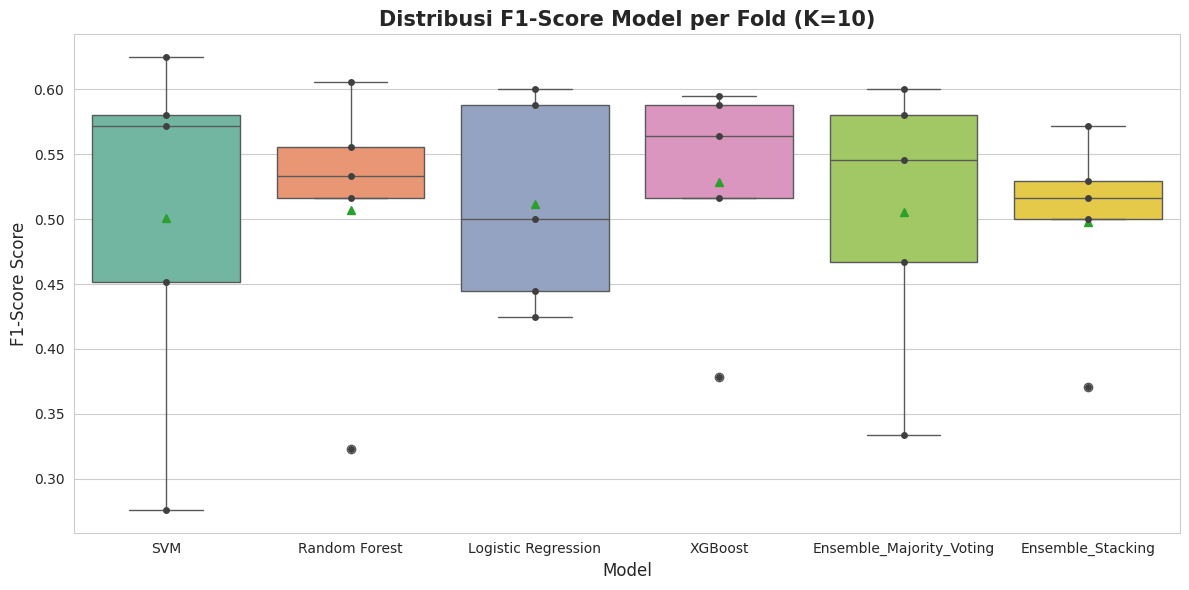

In [ ]:
# ==========================================
# VISUALISASI 1: BOXPLOT HASIL K-FOLD (F1-SCORE)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

# Konversi skor ke DataFrame
df_boxplot = pd.DataFrame(all_model_f1)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Membuat Boxplot
ax = sns.boxplot(data=df_boxplot, palette="Set2", showmeans=True)

# Menambahkan titik data asli (swarmplot) agar lebih detail
sns.swarmplot(data=df_boxplot, color=".25", size=5)

plt.title('Distribusi F1-Score Model per Fold (K=10)', fontsize=15, fontweight='bold')
plt.ylabel('F1-Score Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats
from itertools import combinations
import numpy as np

# 1. Daftar model yang akan dibandingkan
base_models = ["SVM", "Random Forest", "Logistic Regression", "XGBoost"]
ensemble_models = ["Ensemble_Majority_Voting", "Ensemble_Stacking"]

print("="*80)
print("ANALISIS SIGNIFIKANSI STATISTIK: F1-SCORE (PAIRED T-TEST)")
print("Skema: 5-Fold Cross Validation | Alpha: 0.05")
print("="*80 + "\n")

# --- BAGIAN A: PERBANDINGAN ANTAR MODEL TUNGGAL (Untuk BAB IV) ---
print("--- [A] PERBANDINGAN ANTAR MODEL TUNGGAL ---")
for m1, m2 in combinations(base_models, 2):
    scores1 = all_model_f1[m1]
    scores2 = all_model_f1[m2]

    t_stat, p_value = stats.ttest_rel(scores1, scores2)

    print(f"Perbandingan: {m1} vs {m2}")
    print(f"T-Statistic : {t_stat:.4f} | P-Value: {p_value:.4f}")
    if p_value < 0.05:
        better_model = m1 if t_stat > 0 else m2
        print(f"Kesimpulan  : BERBEDA SIGNIFIKAN ({better_model} unggul secara statistik).")
    else:
        print("Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).")
    print("-" * 55)

print("\n" + "="*70 + "\n")

# --- BAGIAN B: PERBANDINGAN ENSEMBLE VS MODEL TUNGGAL (Untuk BAB V) ---
print("--- [B] PERBANDINGAN ENSEMBLE VS MODEL TUNGGAL ---")
for ensemble_name in ensemble_models:
    print(f"##### ANALISIS UNTUK: {ensemble_name} #####")
    for base_name in base_models:
        scores_ensemble = all_model_f1[ensemble_name]
        scores_base = all_model_f1[base_name]

        t_stat, p_value = stats.ttest_rel(scores_ensemble, scores_base)

        print(f"Komparasi   : {ensemble_name} vs {base_name}")
        print(f"T-Statistic : {t_stat:.4f} | P-Value: {p_value:.4f}")

        if p_value < 0.05:
            if t_stat > 0:
                print("Kesimpulan  : Ensemble UNGGUL & BERBEDA SIGNIFIKAN.")
            else:
                print("Kesimpulan  : BERBEDA SIGNIFIKAN (Model Tunggal Lebih Tinggi).")
        else:
            print("Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).")
        print("-" * 55)
    print("\n")

# --- BAGIAN C: KOMPARASI INTERNAL ENSEMBLE (STACKING VS VOTING) ---
print("--- [C] KOMPARASI STACKING VS MAJORITY VOTING ---")
scores_stack = all_model_f1["Ensemble_Stacking"]
scores_vote = all_model_f1["Ensemble_Majority_Voting"]

t_final, p_final = stats.ttest_rel(scores_stack, scores_vote)

print(f"Perbandingan: Ensemble Stacking vs Majority Voting")
print(f"T-Statistic : {t_final:.4f} | P-Value: {p_final:.4f}")

if p_final < 0.05:
    print("Kesimpulan  : Terdapat perbedaan keseimbangan model yang SIGNIFIKAN.")
else:
    print("Kesimpulan  : Stacking dan Majority Voting memiliki tingkat keseimbangan (F1) yang SETARA.")
print("="*80)

ANALISIS SIGNIFIKANSI STATISTIK: F1-SCORE (PAIRED T-TEST)
Skema: 5-Fold Cross Validation | Alpha: 0.05

--- [A] PERBANDINGAN ANTAR MODEL TUNGGAL ---
Perbandingan: SVM vs Random Forest
T-Statistic : -0.2741 | P-Value: 0.7976
Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).
-------------------------------------------------------
Perbandingan: SVM vs Logistic Regression
T-Statistic : -0.1806 | P-Value: 0.8654
Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).
-------------------------------------------------------
Perbandingan: SVM vs XGBoost
T-Statistic : -1.0941 | P-Value: 0.3354
Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).
-------------------------------------------------------
Perbandingan: Random Forest vs Logistic Regression
T-Statistic : -0.0886 | P-Value: 0.9337
Kesimpulan  : Performa Setara (TIDAK SIGNIFIKAN).
-------------------------------------------------------
Perbandingan: Random Forest vs XGBoost
T-Statistic : -1.3724 | P-Value: 0.2419
Kesimpulan  : Performa Setara (T

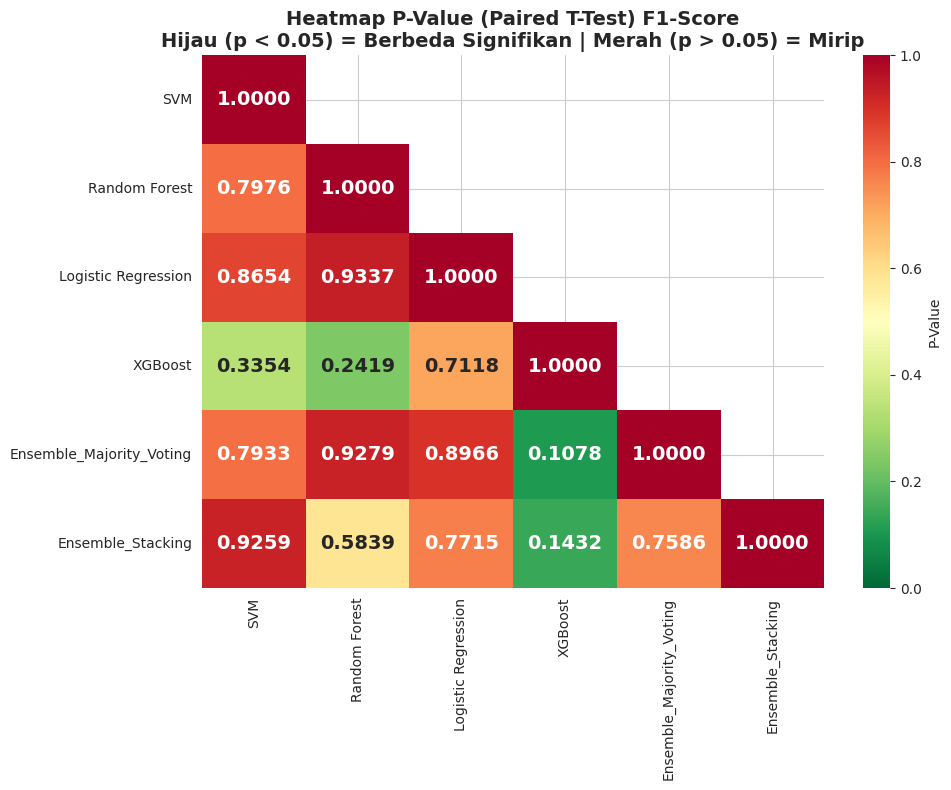

In [ ]:
# ==========================================
# VISUALISASI 2: HEATMAP SIGNIFIKANSI (P-VALUE) - F1-SCORE
# ==========================================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Siapkan matriks kosong untuk menyimpan P-Value
model_names = list(all_model_f1.keys())
n = len(model_names)
p_matrix = np.zeros((n, n))

# 2. Isi matriks dengan P-Value dari hasil T-Test
for i in range(n):
    for j in range(n):
        if i == j:
            p_matrix[i, j] = 1.0 # Perbandingan dengan diri sendiri (P-Value pasti 1)
        else:
            scores_a = all_model_f1[model_names[i]]
            scores_b = all_model_f1[model_names[j]]
            _, p_val = stats.ttest_rel(scores_a, scores_b)
            p_matrix[i, j] = p_val

# 3. Buat Heatmap
plt.figure(figsize=(10, 8))

# Mask untuk menyembunyikan bagian atas (karena matriksnya simetris)
mask = np.triu(np.ones_like(p_matrix, dtype=bool), k=1)

# Menggunakan 'RdYlGn_r' agar:
# Nilai rendah (p < 0.05) -> HIJAU (Signifikan)
# Nilai tinggi (p > 0.05) -> MERAH (Tidak Signifikan)
sns.heatmap(p_matrix, annot=True, fmt=".4f", cmap="RdYlGn_r",
            xticklabels=model_names, yticklabels=model_names,
            mask=mask, vmin=0, vmax=1,annot_kws={"size": 14, "weight": "bold"}, # BESARKAN ANGKA DI DALAM KOTAK
            cbar_kws={'label': 'P-Value'})

plt.title('Heatmap P-Value (Paired T-Test) F1-Score\nHijau (p < 0.05) = Berbeda Signifikan | Merah (p > 0.05) = Mirip',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats
import pandas as pd
import numpy as np

# Ambil skor F1 dari data yang sudah Anda miliki
scores_xgb = all_model_f1["XGBoost"]
scores_stacking = all_model_f1["Ensemble_Stacking"]

# Hitung Paired T-Test
t_stat, p_val = stats.ttest_rel(scores_xgb, scores_stacking)

print("--- ANALISIS TRADE-OFF (F1-MEASURE): XGBOOST VS STACKING ---")
print(f"Rata-rata F1 XGBoost  : {np.mean(scores_xgb):.4f}")
print(f"Rata-rata F1 Stacking : {np.mean(scores_stacking):.4f}")
print(f"P-Value               : {p_val:.4f}")

if p_val < 0.05:
    print("Kesimpulan: Terdapat perbedaan TRADE-OFF yang SIGNIFIKAN.")
else:
    print("Kesimpulan: TIDAK ada perbedaan signifikan (Trade-off seimbang/serupa).")

--- ANALISIS TRADE-OFF (F1-MEASURE): XGBOOST VS STACKING ---
Rata-rata F1 XGBoost  : 0.5283
Rata-rata F1 Stacking : 0.4975
P-Value               : 0.1432
Kesimpulan: TIDAK ada perbedaan signifikan (Trade-off seimbang/serupa).


/tmp/ipykernel_5666/1012088913.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='F1-Score', data=df_plot, palette=['#ff9999','#66b3ff'], showmeans=True)


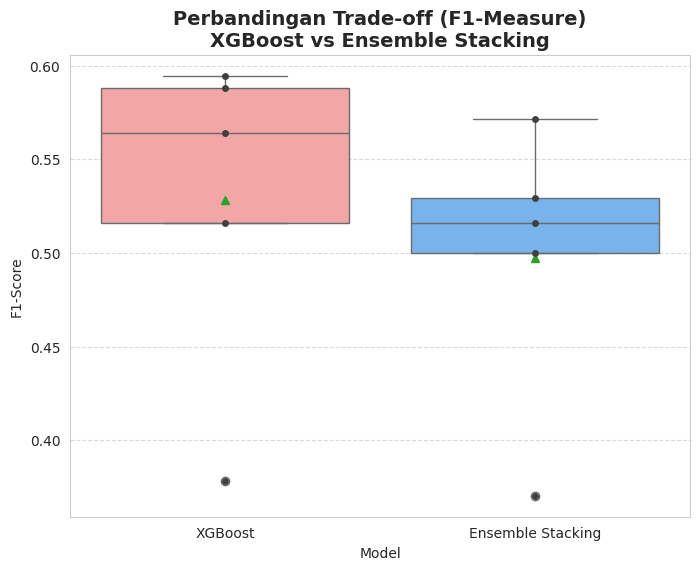

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Siapkan data untuk plot
df_plot = pd.DataFrame({
    'Model': ['XGBoost']*5 + ['Ensemble Stacking']*5,
    'F1-Score': list(scores_xgb) + list(scores_stacking)
})

plt.figure(figsize=(8, 6))
sns.boxplot(x='Model', y='F1-Score', data=df_plot, palette=['#ff9999','#66b3ff'], showmeans=True)
sns.swarmplot(x='Model', y='F1-Score', data=df_plot, color=".25")

plt.title('Perbandingan Trade-off (F1-Measure)\nXGBoost vs Ensemble Stacking', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# # ==========================================
# # VISUALISASI 2: HEATMAP SIGNIFIKANSI (P-VALUE) - F1-SCORE
# # ==========================================
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from scipy import stats

# # 1. Siapkan matriks kosong untuk menyimpan P-Value
# model_names = list(all_model_f1.keys())
# n = len(model_names)
# p_matrix = np.zeros((n, n))

# # 2. Isi matriks dengan P-Value dari hasil T-Test
# for i in range(n):
#     for j in range(n):
#         if i == j:
#             p_matrix[i, j] = 1.0 # Perbandingan dengan diri sendiri (P-Value pasti 1)
#         else:
#             scores_a = all_model_f1[model_names[i]]
#             scores_b = all_model_f1[model_names[j]]
#             _, p_val = stats.ttest_rel(scores_a, scores_b)
#             p_matrix[i, j] = p_val

# # 3. Buat Heatmap
# plt.figure(figsize=(10, 8))

# # Mask untuk menyembunyikan bagian atas (karena matriksnya simetris)
# mask = np.triu(np.ones_like(p_matrix, dtype=bool), k=1)

# # Menggunakan 'RdYlGn_r' agar:
# # Nilai rendah (p < 0.05) -> HIJAU (Signifikan)
# # Nilai tinggi (p > 0.05) -> MERAH (Tidak Signifikan)
# sns.heatmap(p_matrix, annot=True, fmt=".4f", cmap="RdYlGn_r",
#             xticklabels=model_names, yticklabels=model_names,
#             mask=mask, vmin=0, vmax=1,annot_kws={"size": 14, "weight": "bold"}, # BESARKAN ANGKA DI DALAM KOTAK
#             cbar_kws={'label': 'P-Value'})

# plt.title('Heatmap P-Value (Paired T-Test) F1-Score\nHijau (p < 0.05) = Berbeda Signifikan | Merah (p > 0.05) = Mirip',
#           fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

# **SECTION 5: PENGUKURAN EFISIENSI MODEL**
(Waktu Eksekusi, Kompleksitas (Cyclomatic Complexity), Konsumsi Sumber Daya)

  PENGUKURAN EFISIENSI MODEL — WAKTU, RAM & CPU
  (Cyclomatic Complexity: statis, dimasukkan di tabel akhir)

──────────────────────────────────────────────────────────────
  Model  : Logistic Regression
  CC (M) : 3  ← hardcoded dari flowchart, tidak diukur runtime
──────────────────────────────────────────────────────────────
  Fold 1 | Train: 0.028s | Infer: 0.0139ms | RAM: 0.10MB | CPU: 0.0% [peak: 0.0%]
  Fold 2 | Train: 0.066s | Infer: 0.0338ms | RAM: 0.10MB | CPU: 0.0% [peak: 0.0%]
  Fold 3 | Train: 0.130s | Infer: 0.0116ms | RAM: 0.13MB | CPU: 50.0% [peak: 100.0%]
  Fold 4 | Train: 0.025s | Infer: 0.0123ms | RAM: 0.10MB | CPU: 0.0% [peak: 0.0%]
  Fold 5 | Train: 0.029s | Infer: 0.0125ms | RAM: 0.10MB | CPU: 0.0% [peak: 0.0%]

  RERATA → Train: 0.056s | Infer: 0.0168ms | RAM: 0.10MB | CPU: 10.0% [peak: 20.0%]

──────────────────────────────────────────────────────────────
  Model  : SVM
  CC (M) : 3  ← hardcoded dari flowchart, tidak diukur runtime
──────────────────────────────

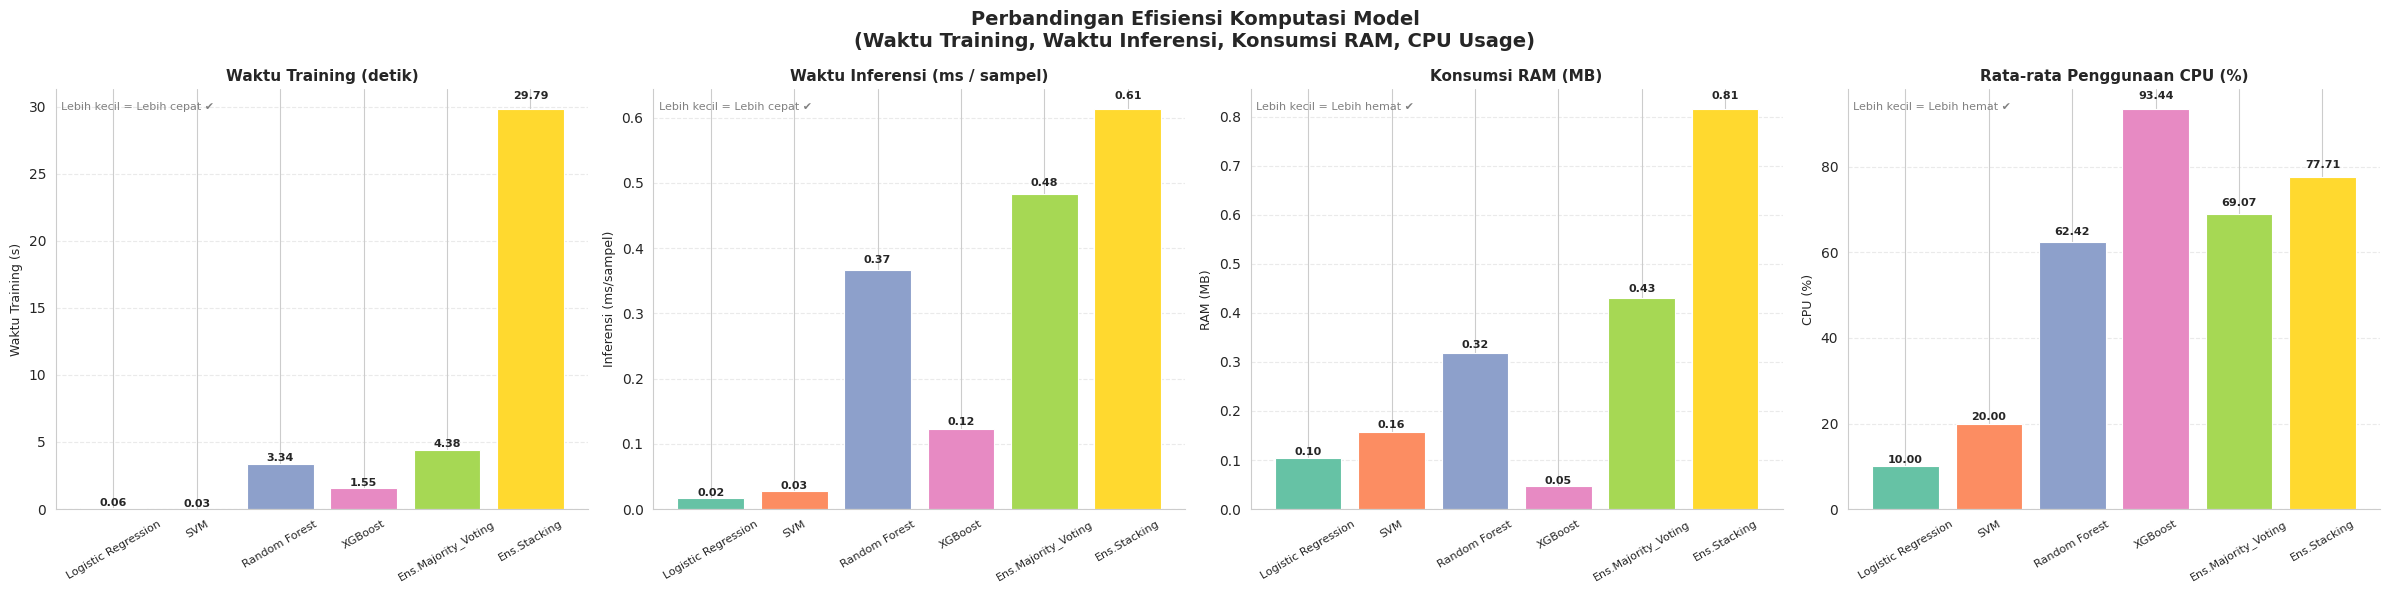

✅ Gambar disimpan: visualisasi_efisiensi_model.png


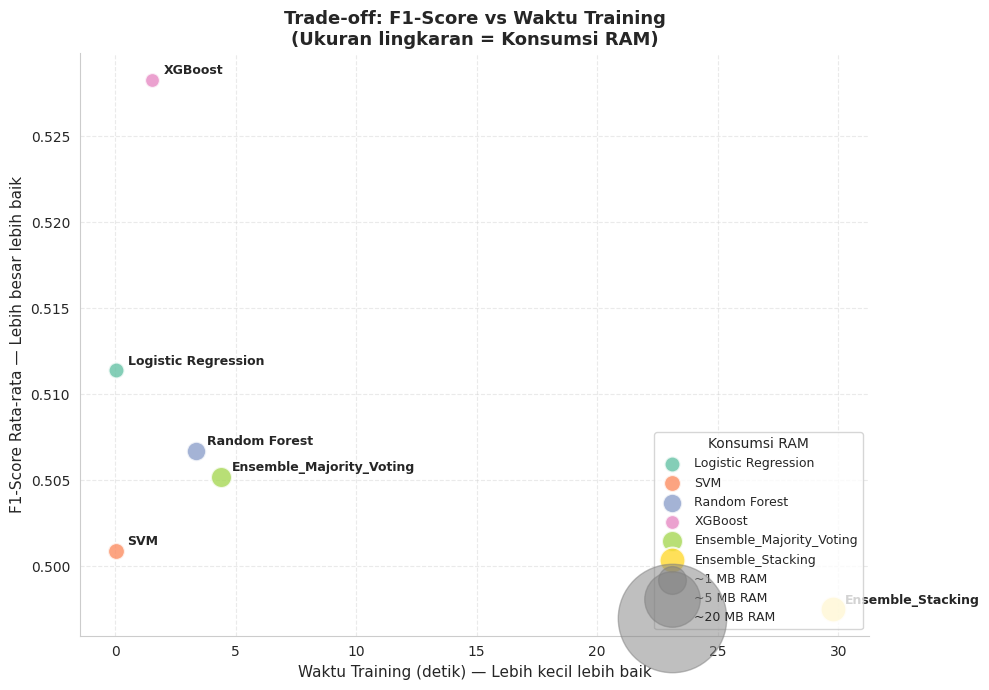

✅ Gambar disimpan: tradeoff_f1_vs_waktu.png

  TABEL KOMPARASI FINAL: PERFORMA + EFISIENSI + CYCLOMATIC COMPLEXITY
                   Model  Accuracy  F1-Score  Precision  Recall  Waktu Training (s)  Inferensi (ms/sampel)  RAM (MB)  CPU (%)  Cyclomatic Complexity (M)
     Logistic Regression    0.6982    0.5114     0.6200  0.4379              0.0558                0.01681    0.1034    10.00                          3
                     SVM    0.7094    0.5009     0.6338  0.4158              0.0250                0.02696    0.1576    20.00                          3
           Random Forest    0.7055    0.5067     0.6300  0.4263              3.3396                0.36635    0.3183    62.42                          6
                 XGBoost    0.6869    0.5283     0.5825  0.4889              1.5471                0.12335    0.0463    93.44                          5
Ensemble_Majority_Voting    0.7168    0.5052     0.6703  0.4058              4.3764                0.48304    0.4298    

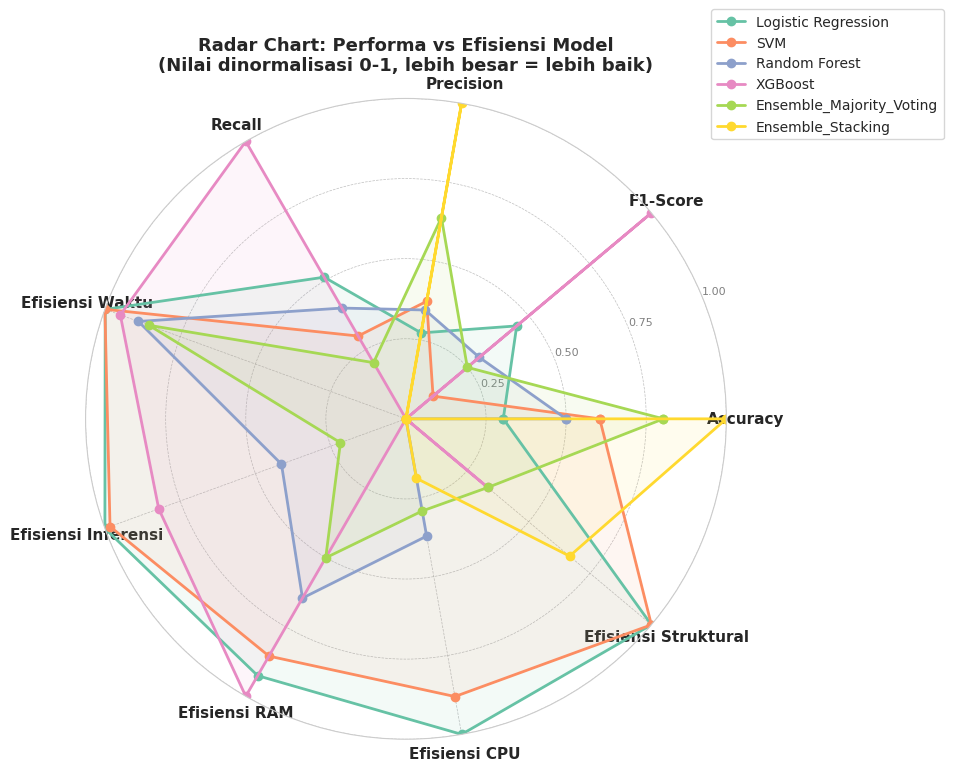

✅ Gambar disimpan: radar_chart_komparasi_final.png

  ANALISIS PENENTUAN MODEL PALING OPTIMAL

  Jumlah dimensi skor komposit : 9
  Formula                      : Skor = Σ(dim_i) / 9
  Normalisasi                  : Min-Max [0, 1]
  Bobot                        : Equal weight (1/9 per dimensi)

  Peringkat  Model                          Skor Komposit   Keterangan
  ─────────────────────────────────────────────────────────────────────────
  #1         Logistic Regression            0.7181         ⭐ PALING OPTIMAL
  #2         SVM                            0.6783         🥈 Runner-up
  #3         XGBoost                        0.5670         🥉 Kandidat Baik
  #4         Ensemble_Majority_Voting       0.4546         
  #5         Random Forest                  0.4292         
  #6         Ensemble_Stacking              0.3172         

  KESIMPULAN:

  Model 'Logistic Regression' dipilih sebagai model PALING OPTIMAL
  dengan Skor Komposit = 0.7181

  Skor komposit dihitung dari rata-rata

In [ ]:
# ============================================================
# SECTION 5: PENGUKURAN EFISIENSI MODEL
# (Waktu Eksekusi & Konsumsi Sumber Daya)
# ============================================================
# Tujuan : Menentukan model PALING OPTIMAL berdasarkan trade-off
#          antara performa (akurasi/F1) dan efisiensi komputasi.
#
# Dimensi yang diukur (4 runtime + 1 statis):
#   1. Waktu Training       - Berapa lama model "belajar" dari data
#   2. Waktu Inferensi      - Berapa lama model membuat prediksi per sampel
#   3. RAM (MB)             - Konsumsi memori puncak saat training
#   4. CPU (%)              - Rata-rata penggunaan CPU saat training
#                             [CPU Peak diukur & ditampilkan di log fold
#                              sebagai informasi tambahan, TIDAK masuk
#                              skor komposit — hanya CPU Avg yang dipakai]
#   5. Cyclomatic Complexity- Kompleksitas alur logika flowchart model
#                             (STATIS — tidak diukur saat runtime,
#                              langsung di-hardcode dari hasil analisis
#                              flowchart SVG; hanya digunakan untuk
#                              tabel komparasi final & skor komposit)
#
# Nilai CC (M = E - N + 2P) dihitung manual dari flowchart:
#   Logistic Regression : M = 3  (N=19, E=20, P=1)
#   SVM                 : M = 3  (N=21, E=22, P=1)
#   Random Forest       : M = 6  (N=21, E=24, P=1)
#   XGBoost             : M = 5  (N=24, E=27, P=1)
#   Ensemble (Voting)   : M = 5  (N=22, E=25, P=1)
#   Ensemble (Stacking) : M = 4  (N=23, E=25, P=1)
#
# Dimensi Skor Komposit (9 dimensi, bobot sama):
#   Performa  : Accuracy, F1-Score, Precision, Recall
#   Efisiensi : Efisiensi Waktu, Efisiensi Inferensi,
#               Efisiensi RAM, Efisiensi CPU, Efisiensi Struktural (CC)
#
# Referensi:
#   Géron, A. (2019). Hands-On Machine Learning with Scikit-Learn,
#     Keras, and TensorFlow (2nd ed.). O'Reilly Media.
#   Domingos, P. (2012). A few useful things to know about machine
#     learning. Communications of the ACM, 55(10), 78–87.
#   Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements
#     of Statistical Learning (2nd ed.). Springer.
#   McCabe, T. J. (1976). A complexity measure. IEEE Transactions on
#     Software Engineering, SE-2(4), 308–320.
#   psutil Documentation. https://psutil.readthedocs.io/
# ============================================================

import time
import tracemalloc
import threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import psutil

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


# ============================================================
# CYCLOMATIC COMPLEXITY — NILAI STATIS (HARDCODED)
# ============================================================
# Nilai dihitung manual dengan rumus M = E - N + 2P
# dari analisis flowchart SVG masing-masing metode.
# TIDAK diukur saat runtime.
# ============================================================
CYCLOMATIC_COMPLEXITY = {
    "Logistic Regression":      3,   # N=18, E=19, P=1
    "SVM":                      3,   # N=20, E=21, P=1
    "Random Forest":            6,   # N=21, E=25, P=1
    "XGBoost":                  5,   # N=24, E=27, P=1
    "Ensemble_Majority_Voting": 5,   # N=22, E=25, P=1
    "Ensemble_Stacking":        4,   # N=23, E=25, P=1
}


# ----------------------------------------------------------
# HELPER: CPU SAMPLER (thread terpisah)
# ----------------------------------------------------------
class CPUSampler:
    """
    Mencatat penggunaan CPU (%) secara periodik di background thread.

    Cara pakai:
        sampler = CPUSampler(interval=0.1)
        sampler.start()
        model.fit(...)
        sampler.stop()
        avg_cpu = sampler.average()
    """
    def __init__(self, interval: float = 0.1):
        self.interval   = interval
        self.samples    = []
        self._stop_flag = threading.Event()
        self._thread    = threading.Thread(target=self._run, daemon=True)

    def _run(self):
        psutil.cpu_percent(interval=None)
        while not self._stop_flag.is_set():
            self.samples.append(psutil.cpu_percent(interval=None))
            time.sleep(self.interval)

    def start(self):
        self._stop_flag.clear()
        self.samples = []
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()

    def stop(self):
        self._stop_flag.set()
        self._thread.join()

    def average(self) -> float:
        return float(np.mean(self.samples)) if self.samples else 0.0

    def peak(self) -> float:
        return float(np.max(self.samples)) if self.samples else 0.0


# ----------------------------------------------------------
# 1. INISIALISASI MODEL
# ----------------------------------------------------------
lr_model  = LogisticRegression(max_iter=217, random_state=42)
svm_model = SVC(probability=True, max_iter=-1, random_state=42)
rf_model  = RandomForestClassifier(n_estimators=197, random_state=42)
xgb_model = XGBClassifier(n_estimators=2003, learning_rate=0.05,
                           eval_metric='logloss', random_state=42)

models = {
    "Logistic Regression": lr_model,
    "SVM":                 svm_model,
    "Random Forest":       rf_model,
    "XGBoost":             xgb_model,
    "Ensemble_Majority_Voting": VotingClassifier(
        estimators=[
            ('lr',  LogisticRegression(max_iter=217, random_state=42)),
            ('svm', SVC(probability=True, max_iter=-1, random_state=42)),
            ('rf',  RandomForestClassifier(n_estimators=197, random_state=42)),
            ('xgb', XGBClassifier(n_estimators=2003, learning_rate=0.05,
                                  eval_metric='logloss', random_state=42))
        ],
        voting='hard'
    ),
    "Ensemble_Stacking": StackingClassifier(
        estimators=[
            ('lr',  LogisticRegression(max_iter=217, random_state=42)),
            ('svm', SVC(probability=True, max_iter=-1, random_state=42)),
            ('rf',  RandomForestClassifier(n_estimators=197, random_state=42)),
            ('xgb', XGBClassifier(n_estimators=2003, learning_rate=0.05,
                                  eval_metric='logloss', random_state=42))
        ],
        final_estimator=LogisticRegression(random_state=42)
    )
}


# ----------------------------------------------------------
# 2. PENGUKURAN UTAMA: Training Time, Inference Time, RAM, CPU
#    → CPU Peak diukur & ditampilkan di log fold sebagai
#      informasi tambahan, tetapi TIDAK masuk skor komposit.
#    → Cyclomatic Complexity TIDAK diukur di sini.
# ----------------------------------------------------------
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

efficiency_results = []

print("=" * 72)
print("  PENGUKURAN EFISIENSI MODEL — WAKTU, RAM & CPU")
print("  (Cyclomatic Complexity: statis, dimasukkan di tabel akhir)")
print("=" * 72)

for model_name, model in models.items():
    print(f"\n{'─'*62}")
    print(f"  Model  : {model_name}")
    print(f"  CC (M) : {CYCLOMATIC_COMPLEXITY[model_name]}"
          f"  ← hardcoded dari flowchart, tidak diukur runtime")
    print(f"{'─'*62}")

    fold_training_times  = []
    fold_inference_times = []
    fold_ram_mb          = []   # RAM (MB) — nama dipersingkat
    fold_cpu_avg         = []   # CPU (%) rata-rata — yang masuk skor komposit
    fold_cpu_peak        = []   # CPU Peak — informasi tambahan saja

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train_f = X.iloc[train_idx]
        X_test_f  = X.iloc[test_idx]
        y_train_f = y.iloc[train_idx]

        X_train_sc = scaler.fit_transform(X_train_f)
        X_test_sc  = scaler.transform(X_test_f)

        # ── TRAINING TIME + RAM + CPU ───────────────────────────
        cpu_sampler = CPUSampler(interval=0.1)

        tracemalloc.start()
        cpu_sampler.start()
        t_train_start = time.perf_counter()

        model.fit(X_train_sc, y_train_f)

        t_train_end = time.perf_counter()
        cpu_sampler.stop()
        _, mem_peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        training_time = t_train_end - t_train_start
        ram_mb        = mem_peak / (1024 ** 2)
        avg_cpu_pct   = cpu_sampler.average()   # ← masuk skor komposit
        peak_cpu_pct  = cpu_sampler.peak()      # ← informasi tambahan saja

        # ── INFERENCE TIME (per sampel) ─────────────────────────
        t_infer_start = time.perf_counter()
        _ = model.predict(X_test_sc)
        t_infer_end   = time.perf_counter()

        inference_per_ms = ((t_infer_end - t_infer_start) / len(X_test_f)) * 1000

        # ── LOG PER FOLD ────────────────────────────────────────
        # CPU Peak ditampilkan di log sebagai referensi, tidak masuk tabel
        print(f"  Fold {fold_idx} | Train: {training_time:.3f}s | "
              f"Infer: {inference_per_ms:.4f}ms | "
              f"RAM: {ram_mb:.2f}MB | "
              f"CPU: {avg_cpu_pct:.1f}% [peak: {peak_cpu_pct:.1f}%]")

        fold_training_times.append(training_time)
        fold_inference_times.append(inference_per_ms)
        fold_ram_mb.append(ram_mb)
        fold_cpu_avg.append(avg_cpu_pct)
        fold_cpu_peak.append(peak_cpu_pct)

    # ── RERATA ─────────────────────────────────────────────────
    avg_train    = np.mean(fold_training_times)
    avg_infer    = np.mean(fold_inference_times)
    avg_ram      = np.mean(fold_ram_mb)
    avg_cpu      = np.mean(fold_cpu_avg)
    avg_cpu_peak = np.mean(fold_cpu_peak)   # disimpan tapi tidak masuk komposit

    print(f"\n  RERATA → Train: {avg_train:.3f}s | "
          f"Infer: {avg_infer:.4f}ms | "
          f"RAM: {avg_ram:.2f}MB | "
          f"CPU: {avg_cpu:.1f}% [peak: {avg_cpu_peak:.1f}%]")

    efficiency_results.append({
        "Model":                       model_name,
        "Waktu Training (s)":          round(avg_train, 4),
        "Inferensi (ms/sampel)":       round(avg_infer, 5),
        "RAM (MB)":                    round(avg_ram, 4),
        "CPU (%)":                     round(avg_cpu, 2),
        # CC statis — diambil dari dictionary, bukan diukur runtime
        "Cyclomatic Complexity (M)":   CYCLOMATIC_COMPLEXITY[model_name],
        # Data per fold untuk keperluan uji statistik
        "_fold_train":                 fold_training_times,
        "_fold_infer":                 fold_inference_times,
        "_fold_ram":                   fold_ram_mb,
        "_fold_cpu_avg":               fold_cpu_avg,
        "_fold_cpu_peak":              fold_cpu_peak,   # disimpan, tidak masuk komposit
    })


# ----------------------------------------------------------
# 3. TABEL RINGKASAN EFISIENSI
# ----------------------------------------------------------
df_eff = pd.DataFrame(efficiency_results)

print("\n" + "=" * 72)
print("  TABEL RINGKASAN EFISIENSI MODEL")
print("  Referensi: Géron (2019); Domingos (2012); Hastie et al. (2009)")
print("=" * 72)

cols_display = ["Model", "Waktu Training (s)", "Inferensi (ms/sampel)",
                "RAM (MB)", "CPU (%)", "Cyclomatic Complexity (M)"]
print(df_eff[cols_display].to_string(index=False))


# ----------------------------------------------------------
# 4. VISUALISASI 1: BAR CHART 4 DIMENSI EFISIENSI RUNTIME
# ----------------------------------------------------------
model_labels = [m.replace("Ensemble_", "Ens.") for m in df_eff["Model"]]
palette      = sns.color_palette("Set2", n_colors=len(df_eff))

metrics = [
    ("Waktu Training (s)",    "Waktu Training (detik)",        "Lebih kecil = Lebih cepat ✔"),
    ("Inferensi (ms/sampel)", "Waktu Inferensi (ms / sampel)", "Lebih kecil = Lebih cepat ✔"),
    ("RAM (MB)",              "Konsumsi RAM (MB)",             "Lebih kecil = Lebih hemat ✔"),
    ("CPU (%)",               "Rata-rata Penggunaan CPU (%)",  "Lebih kecil = Lebih hemat ✔"),
]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle(
    "Perbandingan Efisiensi Komputasi Model\n"
    "(Waktu Training, Waktu Inferensi, Konsumsi RAM, CPU Usage)",
    fontsize=14, fontweight='bold'
)

for ax, (col, title, note) in zip(axes, metrics):
    vals = df_eff[col].values
    bars = ax.bar(model_labels, vals, color=palette,
                  edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(col, fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.annotate(note, xy=(0.01, 0.97), xycoords="axes fraction",
                fontsize=8, color="gray", va="top")
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("visualisasi_efisiensi_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gambar disimpan: visualisasi_efisiensi_model.png")


# ----------------------------------------------------------
# 5. VISUALISASI 2: SCATTER PLOT TRADE-OFF F1 vs WAKTU TRAINING
# ----------------------------------------------------------
if 'all_model_f1' in dir():
    fig2, ax2 = plt.subplots(figsize=(10, 7))
    palette2  = sns.color_palette("Set2", n_colors=len(df_eff))

    f1_means = {m: round(np.mean(s), 4) for m, s in all_model_f1.items()}
    df_eff["F1-Score (Rata-rata)"] = df_eff["Model"].map(f1_means)

    scatter_sizes = (df_eff["RAM (MB)"] * 300 + 100).values

    for i, row in df_eff.iterrows():
        ax2.scatter(row["Waktu Training (s)"],
                    row["F1-Score (Rata-rata)"],
                    s=scatter_sizes[i], color=palette2[i],
                    alpha=0.8, edgecolors="white", linewidth=1.5,
                    label=row["Model"], zorder=3)
        ax2.annotate(row["Model"],
                     (row["Waktu Training (s)"], row["F1-Score (Rata-rata)"]),
                     textcoords="offset points", xytext=(8, 4),
                     fontsize=9, fontweight="bold")

    ax2.set_xlabel("Waktu Training (detik) — Lebih kecil lebih baik", fontsize=11)
    ax2.set_ylabel("F1-Score Rata-rata — Lebih besar lebih baik", fontsize=11)
    ax2.set_title("Trade-off: F1-Score vs Waktu Training\n"
                  "(Ukuran lingkaran = Konsumsi RAM)", fontsize=13, fontweight="bold")
    ax2.grid(True, linestyle='--', alpha=0.4)

    for size_mb in [1, 5, 20]:
        ax2.scatter([], [], s=size_mb * 300 + 100, c='gray', alpha=0.5,
                    label=f"~{size_mb} MB RAM")
    ax2.legend(title="Konsumsi RAM", loc="lower right", fontsize=9)

    sns.despine(ax=ax2)
    plt.tight_layout()
    plt.savefig("tradeoff_f1_vs_waktu.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Gambar disimpan: tradeoff_f1_vs_waktu.png")
else:
    print("⚠️  Variabel 'all_model_f1' tidak ditemukan.")


# ----------------------------------------------------------
# 6. TABEL KOMPARASI FINAL (PERFORMA + EFISIENSI + CC)
# ----------------------------------------------------------
print("\n" + "=" * 72)
print("  TABEL KOMPARASI FINAL: PERFORMA + EFISIENSI + CYCLOMATIC COMPLEXITY")
print("=" * 72)

perf_dicts = {}
metric_sources = {
    "Accuracy":  "all_model_scores",
    "F1-Score":  "all_model_f1",
    "Precision": "all_model_precision",
    "Recall":    "all_model_recall",
}

for metric_label, var_name in metric_sources.items():
    if var_name in dir():
        for model_name, scores in eval(var_name).items():
            if model_name not in perf_dicts:
                perf_dicts[model_name] = {}
            perf_dicts[model_name][metric_label] = round(np.mean(scores), 4)

final_rows = []
for _, row in df_eff.iterrows():
    m     = row["Model"]
    entry = {"Model": m}
    entry.update(perf_dicts.get(m, {}))
    entry["Waktu Training (s)"]        = row["Waktu Training (s)"]
    entry["Inferensi (ms/sampel)"]     = row["Inferensi (ms/sampel)"]
    entry["RAM (MB)"]                  = row["RAM (MB)"]
    entry["CPU (%)"]                   = row["CPU (%)"]
    entry["Cyclomatic Complexity (M)"] = row["Cyclomatic Complexity (M)"]
    final_rows.append(entry)

df_final = pd.DataFrame(final_rows)
print(df_final.to_string(index=False))

df_final.to_csv("komparasi_final_semua_model.csv", index=False)
print("\n✅ Tabel disimpan: komparasi_final_semua_model.csv")


# ----------------------------------------------------------
# 7. VISUALISASI 3: RADAR CHART KOMPARASI FINAL
# ----------------------------------------------------------
# Dimensi Radar: 9 dimensi
# Performa  (4): Accuracy, F1-Score, Precision, Recall
# Efisiensi (5): Waktu, Inferensi, RAM, CPU, Struktural (CC)
# ----------------------------------------------------------
radar_cols = ["Accuracy", "F1-Score", "Precision", "Recall",
              "Efisiensi Waktu", "Efisiensi Inferensi",
              "Efisiensi RAM", "Efisiensi CPU", "Efisiensi Struktural"]

df_radar = df_final.copy()

# Normalisasi performa — lebih besar = lebih baik (TIDAK diinvers)
for col in ["Accuracy", "F1-Score", "Precision", "Recall"]:
    if col in df_radar.columns:
        v = df_radar[col]
        df_radar[col] = (v - v.min()) / (v.max() - v.min() + 1e-9)

# Normalisasi efisiensi — lebih kecil = lebih baik (DIINVERS: 1 - norm)
efisiensi_map = {
    "Waktu Training (s)":        "Efisiensi Waktu",
    "Inferensi (ms/sampel)":     "Efisiensi Inferensi",
    "RAM (MB)":                  "Efisiensi RAM",
    "CPU (%)":                   "Efisiensi CPU",
    "Cyclomatic Complexity (M)": "Efisiensi Struktural",
}
for raw_col, norm_col in efisiensi_map.items():
    if raw_col in df_radar.columns:
        v = df_radar[raw_col]
        df_radar[norm_col] = 1 - (v - v.min()) / (v.max() - v.min() + 1e-9)

radar_cols_avail = [c for c in radar_cols if c in df_radar.columns]
N      = len(radar_cols_avail)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig3, ax3 = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
radar_palette = sns.color_palette("Set2", n_colors=len(df_radar))

for i, (_, row) in enumerate(df_radar.iterrows()):
    values = [row.get(c, 0) for c in radar_cols_avail]
    values += values[:1]
    ax3.plot(angles, values, 'o-', linewidth=2,
             color=radar_palette[i], label=row["Model"])
    ax3.fill(angles, values, alpha=0.08, color=radar_palette[i])

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(radar_cols_avail, fontsize=11, fontweight="bold")
ax3.set_yticks([0.25, 0.5, 0.75, 1.0])
ax3.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=8, color="gray")
ax3.set_ylim(0, 1)
ax3.set_title("Radar Chart: Performa vs Efisiensi Model\n"
              "(Nilai dinormalisasi 0-1, lebih besar = lebih baik)",
              fontsize=13, fontweight="bold", pad=20)
ax3.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax3.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig("radar_chart_komparasi_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gambar disimpan: radar_chart_komparasi_final.png")


# ----------------------------------------------------------
# 8. KESIMPULAN OTOMATIS: MODEL PALING OPTIMAL
# ----------------------------------------------------------
print("\n" + "=" * 72)
print("  ANALISIS PENENTUAN MODEL PALING OPTIMAL")
print("=" * 72)

# 9 dimensi skor komposit — sesuai radar chart
score_cols       = ["Accuracy", "F1-Score", "Precision", "Recall",
                    "Efisiensi Waktu", "Efisiensi Inferensi",
                    "Efisiensi RAM", "Efisiensi CPU", "Efisiensi Struktural"]
avail_score_cols = [c for c in score_cols if c in df_radar.columns]

# Skor komposit = rata-rata sederhana (equal weight) 9 dimensi
df_radar["Skor Komposit"] = df_radar[avail_score_cols].mean(axis=1)
df_sorted = df_radar.sort_values("Skor Komposit", ascending=False).reset_index(drop=True)

print(f"\n  Jumlah dimensi skor komposit : {len(avail_score_cols)}")
print(f"  Formula                      : Skor = Σ(dim_i) / {len(avail_score_cols)}")
print(f"  Normalisasi                  : Min-Max [0, 1]")
print(f"  Bobot                        : Equal weight (1/{len(avail_score_cols)} per dimensi)\n")

print(f"  {'Peringkat':<10} {'Model':<30} {'Skor Komposit':<15} {'Keterangan'}")
print("  " + "─" * 73)

labels = ["⭐ PALING OPTIMAL", "🥈 Runner-up", "🥉 Kandidat Baik", "", "", ""]
for rank, (_, row) in enumerate(df_sorted.iterrows(), start=1):
    print(f"  #{rank:<9} {row['Model']:<30} {row['Skor Komposit']:.4f}         {labels[rank-1]}")

best_model = df_sorted.iloc[0]["Model"]
best_score = df_sorted.iloc[0]["Skor Komposit"]

print(f"""
{'='*72}
  KESIMPULAN:

  Model '{best_model}' dipilih sebagai model PALING OPTIMAL
  dengan Skor Komposit = {best_score:.4f}

  Skor komposit dihitung dari rata-rata normalisasi 9 dimensi:

  [Performa — lebih besar lebih baik, normalisasi normal]
  ✔ Accuracy             — Ketepatan prediksi secara keseluruhan
  ✔ F1-Score             — Keseimbangan presisi dan recall
  ✔ Precision            — Ketepatan prediksi positif
  ✔ Recall               — Kemampuan mendeteksi kasus positif

  [Efisiensi — lebih kecil lebih baik, normalisasi diinvers]
  ✔ Efisiensi Waktu      — Kecepatan training
  ✔ Efisiensi Inferensi  — Kecepatan prediksi per sampel
  ✔ Efisiensi RAM        — Hemat memori saat training
  ✔ Efisiensi CPU        — Hemat CPU saat training (rata-rata, bukan peak)
  ✔ Efisiensi Struktural — CC rendah = alur logika lebih sederhana
                           [Nilai statis dari analisis flowchart SVG]

  Catatan:
    CPU Peak diukur & ditampilkan di log fold sebagai informasi
    tambahan, tetapi TIDAK dimasukkan ke skor komposit untuk
    menghindari double-counting dengan CPU (rata-rata).

  Referensi:
  Géron, A. (2019). Hands-On Machine Learning. O'Reilly Media.
  Domingos, P. (2012). Communications of the ACM, 55(10), 78–87.
  Hastie et al. (2009). The Elements of Statistical Learning. Springer.
  McCabe, T. J. (1976). IEEE Transactions on Software Engineering, SE-2(4).
  psutil Documentation. https://psutil.readthedocs.io/

  Model dengan skor komposit tertinggi menawarkan keseimbangan
  terbaik antara PERFORMA KLASIFIKASI, EFISIENSI KOMPUTASI,
  dan KESEDERHANAAN STRUKTURAL ALGORITMA.
{'='*72}
""")